<h1 align="center">Visual Learning: inhibitory cell types and physiology across learning</h1>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>The experiment</h2>

The Visual Learning dataset asks how **inhibitory cell-type-specific coding and interactions change as
an animal learns**. The same neurons are imaged longitudinally across the whole of learning, and their
cell types are recovered afterwards from gene expression.

The usual way to study a specific inhibitory cell type is a transgenic driver line — `Vip-IRES-Cre`
labels Vip cells, and you record those. That gives you one cell type at a time, in separate animals.
This experiment inverts it: label **all** inhibitory neurons, record them together, and work out which
type each one was *after the fact* using post-hoc spatial transcriptomics. Because type comes from
measured expression rather than from the driver line, multiple cell types are recorded
**simultaneously in the same animal** — which is what makes questions about *interactions between*
types accessible.

<h3>In vivo: imaging through learning</h3>

Mice express GCaMP8s in inhibitory neurons (`Slc32a1-IRES-Cre;Oi1` — Slc32a1 is also known as VGAT).
Two-photon imaging covers **8 planes in V1 (VISp)**, at depths from roughly 50 to 350 µm — about layer
1 through upper layer 5. Imaging runs through **every stage of the training curriculum**, from the
first naive session to expert performance, and the same cells are tracked from session to session.

This is the key difference from the previously released **Visual Behavior Ophys** dataset, which used
the same training curriculum but only imaged well-trained mice. Here, learning itself is in the
neural data.

After training, mice also run **passive viewing** sessions — drifting gratings and natural movies, no
task and no reward — which support mapping receptive-field properties for the same neurons.

<h3>Post hoc: gene expression in the same cells</h3>

A 350-400 µm section from the same brain is **cleared and expanded**, then probed for mRNA transcripts
using **hybridization chain reaction (HCR)**, imaged with light-sheet microscopy. Five genes are
mapped per round over several rounds, for **18-24 genes per mouse**. Values are *spot counts* —
individual transcripts detected as fluorescent puncta.

The panel targets known subtypes within the four main inhibitory subclasses — **Pvalb, Sst, Vip,
Lamp5** — with markers such as `Ndnf` (neurogliaform), `Cck` (basket), `Calb2` (Sst Martinotti and Vip
bipolar), plus `Crh`, `Reln`, `Npy`, `Chat` and others.

<h3>Linking the two</h3>

Registration is a chain, not a single step: ROIs are matched **across sessions** within each imaging
plane (with ROICaT), that unified set of masks is mapped into a high-resolution **2P structural volume**
containing all 8 planes, and that volume is aligned to the light-sheet volume from the same brain. The
process is semi-automated and ends in manual QC.

Two consequences follow directly, and they shape every analysis below:

- The structural volume spans 400 µm while only 8 planes carry functional data, so **many structural
  cells have no functional counterpart**.
- **Not every neuron in an imaging plane maps to an HCR cell**, and not every neuron is matched in
  every session — activity differences, segmentation errors and drift all cost matches.

The neurons that do make it through are the opportunity: inhibitory circuit interactions with genetic
identity attached, and a handle on how functional diversity relates to genetic diversity.

<h3>A caution on cell type labels</h3>

The subclass labels used here are useful but **not ground truth**. Cell typing from a few dozen genes
is hard — published taxonomies are built from single-cell sequencing of hundreds to thousands of genes,
a different modality with different SNR — and taxonomies keep evolving. Treat the labels as one
reasonable classification among several, and consider using the graded expression patterns directly
when a result hinges on them.

<h3>What this notebook does</h3>

It shows how to load ophys data for a given session type, and how to attach inhibitory subclass labels
to the neurons in it using the tables that link the two modalities. Getting there takes two kinds of
alignment, and most of the notebook is about doing them correctly:

- **Across modalities** — matching an imaged neuron to its transcriptomic cell type (Part 3)
- **Across sessions** — matching a neuron imaged on one day to the same neuron on another day (Part 7)

Everything is done by **reading the NWB file directly** — no loader library, no wrapper class. The
point is that you can see every step: which container a piece of data lives in, what shape it comes
back as, and which identifier links it to the next piece.

Once the labels are attached, we make the same four plots for each session type:

| Plot | What it shows |
| --- | --- |
| Max projections by depth | where the neurons are, coloured by cell type |
| dF/F heatmaps | all activity in the session, then sorted by cell type |
| Tuning heatmap | which stimulus each neuron prefers |
| Change-aligned response | activity locked to the moment the image changes |

We do this first for a **gratings** session, then for two **natural image** sessions, and finally
compare the same neurons across two of those sessions.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>The data</h2>

Code Ocean mounts each attached data asset read-only under `/data`, in a folder named
after the asset. This tutorial needs three assets, plus the metadata table:

| Asset | What it provides |
| --- | --- |
| `Visual-Learning-SWDB` | one NWB per imaging session: activity, behavior, ROI masks |
| `Visual-Learning-Cell-Gene-Tables` | per-mouse cell x gene **AnnData**, carrying the cell-type labels |
| `Visual-Learning-Coreg-Tables` | the ID table linking imaged ROIs to HCR cells |
| `/data/metadata/visual_learning_session_metadata.csv` | one row per session: mouse, date, session type |

The division of labour between the two HCR-side assets is worth being explicit about, because it is
the part people get wrong:

- The **coregistration asset** answers *"which HCR cell is this imaged ROI?"*. It is a table of
  **identifiers only** — no expression, no cell types.
- The **cell x gene AnnData** answers *"what type is that HCR cell, and what genes does it express?"*.
  It knows nothing about imaging.

Neither is useful alone. The coreg table's `hcr_id` is the key that opens the AnnData.

If a folder is missing, the asset is not attached — attach it in the capsule's Data panel.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Setup</h2>

</div>

In [1]:
import ast
import gc
import os
import glob

import numpy as np
import pandas as pd
import anndata as ad
import pynwb
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# Show wide tables without pandas truncating the middle columns.
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

# Every attached data asset appears as its own directory under /data.
data_dir = '/data'

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 15,
    'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 13,
    'figure.titlesize': 18, 'figure.dpi': 100,
})

sorted(os.listdir(data_dir))

['409828_V1DD_Filtered',
 '416296_V1DD_Filtered',
 '427836_V1DD_Filtered',
 '438833_V1DD_Filtered',
 'Neuropixels_Opto_ecephys_nwb_combined',
 'Visual-Learning-Cell-Gene-Tables',
 'Visual-Learning-Coreg-Tables',
 'Visual-Learning-SWDB',
 'brain-computer-interface-v2',
 'dynamicrouting_datacube',
 'metadata']

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Part 1: Find sessions using the session metadata table</h2>

Before opening any data file, look at the **session metadata table**. It has one row per session
across the whole dataset — which mouse, which day, which training or imaging stage — so it is the
fastest way to find the sessions worth analyzing. Filenames alone will not tell you what stage a
session was.

</div>

In [2]:
# One row per imaging session, across every mouse in the dataset.
session_metadata = pd.read_csv(
    os.path.join(data_dir, 'metadata', 'visual_learning_session_metadata.csv'))

print('sessions:', session_metadata.shape)
print('mice:    ', sorted(session_metadata['subject_id'].unique()))
print()
print('columns:', session_metadata.columns.tolist())

sessions: (147, 25)
mice:     [np.int64(782149), np.int64(788406), np.int64(790322), np.int64(800792), np.int64(800995), np.int64(804363)]

columns: ['subject_id', 'session_id', 'name', 'session_type', 'acquisition_type', 'stage', 'image_set', 'session_number', 'acquisition_date', 'session_date', 'session_time', 'age_days', 'genotype', 'sex', 'date_of_birth', 'rig', 'project_name', 'n_planes', 'plane_names', 'imaging_depths', 'targeted_structures', 'planes_failing_zdrift', 'n_planes_failing_zdrift', 'processed_stamp', '_id']


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

This table is built from the **aind-data-schema v2** metadata, so a few column names differ from
what you may have seen in older notebooks. The ones we use:

| Column | Meaning |
| --- | --- |
| `subject_id` | which mouse |
| `session_id` | the acquisition name, which is how the NWB file is named |
| `name` | the full processed-asset name: `<session_id>_processed_<stamp>` |
| `session_number` | order the sessions were acquired in, per mouse |
| `session_date` | acquisition date — this becomes part of the ROI identifiers later on |
| `session_type` | the training or imaging stage (see the next section) |
| `stage` | just the stage prefix of `session_type`, e.g. `OPHYS_4` — handy for grouping |
| `image_set` | which set of natural images (A or B), if any |
| `n_planes`, `plane_names`, `imaging_depths` | the imaging planes and their depths in microns |
| `planes_failing_zdrift` | how many of this session's planes failed the z-drift QC check |

Three v2 details worth knowing before you index into it:

- **`acquisition_type` is the v2 name for `session_type`**, and both columns are present here
  holding identical values. Use either; this notebook uses `session_type`.
- **`plane_names`, `imaging_depths` and `targeted_structures` are lists stored as strings** —
  `"['VISp_0', 'VISp_1', ...]"` — because a CSV cell holds one value. Parse them with
  `ast.literal_eval` before using them, or you will be indexing into a string character by
  character.
- **`imaging_depths` is in the same order as `plane_names`, not sorted.** `VISp_0` is not
  necessarily the most superficial plane, so `zip` the two lists rather than assuming.

Pick one mouse and list its sessions in acquisition order. This is that animal's whole experimental
history, top to bottom.

</div>

In [3]:
# EDIT: any mouse in the table above. 800995 has all three session types this notebook uses.
mouse = 800995

mouse_sessions = (session_metadata[session_metadata['subject_id'] == mouse]
                  .sort_values('session_number'))

mouse_sessions[['session_number', 'session_date', 'session_type', 'stage', 'image_set',
                'age_days', 'n_planes', 'planes_failing_zdrift', 'session_id']]

,session_number,session_date,session_type,stage,image_set,age_days,n_planes,planes_failing_zdrift,session_id
105,1,2025-08-05,TRAINING_0_gratings_autorewards_15min,TRAINING_0,NaN,120,8,NaN,multiplane-ophys_800995_2025-08-05_13-25-58
106,2,2025-08-07,TRAINING_1_gratings,TRAINING_1,NaN,122,8,NaN,multiplane-ophys_800995_2025-08-07_12-29-04
107,3,2025-08-08,TRAINING_1_gratings,TRAINING_1,NaN,123,8,NaN,multiplane-ophys_800995_2025-08-08_12-49-42
108,4,2025-08-11,TRAINING_1_gratings,TRAINING_1,NaN,126,8,NaN,multiplane-ophys_800995_2025-08-11_11-02-36
109,5,2025-08-12,TRAINING_2_gratings_flashed,TRAINING_2,NaN,127,8,NaN,multiplane-ophys_800995_2025-08-12_10-33-26
110,6,2025-08-13,TRAINING_3_images_A_10uL_reward,TRAINING_3,A,128,8,[],multiplane-ophys_800995_2025-08-13_10-35-25
111,7,2025-08-14,TRAINING_3_images_A_10uL_reward,TRAINING_3,A,129,8,NaN,multiplane-ophys_800995_2025-08-14_12-22-10
112,8,2025-08-15,TRAINING_3_images_A_10uL_reward,TRAINING_3,A,130,8,NaN,multiplane-ophys_800995_2025-08-15_12-44-14
113,9,2025-08-18,TRAINING_4_images_A_training,TRAINING_4,A,133,8,NaN,multiplane-ophys_800995_2025-08-18_12-03-27
114,10,2025-08-19,TRAINING_5_images_A_epilogue,TRAINING_5,A,134,8,[],multiplane-ophys_800995_2025-08-19_10-54-26


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>What the session types mean</h3>

**Every session in this dataset has two-photon imaging.** This is the single most important thing to
understand about `session_type`, and the naming makes it slightly confusing.

This dataset uses the same behavioral training curriculum as **Visual Behavior Ophys** (https://allenswdb.github.io/physiology/stimuli/visual-behavior/VB-Behavior.html), and inherited
its `session_type` names. In that dataset mice were trained in a behavior facility and only *then*
placed under the microscope, so `TRAINING_` versus `OPHYS_` really did mean behavior-only versus
imaging. **Here it does not.** Mice are imaged throughout the entire learning process, from the first
naive session onward.

`TRAINING_` still means training — the mouse is genuinely still learning the task. What the prefix
does *not* mean is "no physiology": there is ophys during those sessions too. The boundary between the
two prefixes is **behavioral**: by the time a mouse reaches `OPHYS_`, it has hit criterion performance
on the natural-image version of the task.

You can confirm the imaging part from the metadata table itself: every row, `TRAINING_` and `OPHYS_`
and `STAGE_` alike, has `n_planes == 8`.

| prefix | What it means | Task? | Ophys? |
| --- | --- | --- | --- |
| `TRAINING_` | Still learning: naive through to criterion | yes | yes |
| `OPHYS_` | At criterion on natural images; now manipulations — familiar, novel, extinction | yes | yes |
| `STAGE_` | Passive viewing, no task and no reward | no | yes |

The rest of the name is a number giving position in the sequence, the image set (`images_A` or
`images_B`), and any session-specific suffix.

**The task.** Images flash continuously and the mouse licks to report when the image identity changes.
On a *go* trial the image changes — licking within 750 ms is a **hit** and earns water, not licking is
a **miss**. On a *catch* trial no change occurs, so licking is a **false alarm**. Licking before the
scheduled change aborts the trial.

<h4>Learning the task (`TRAINING_`, still training)</h4>

| `session_type` | What happens |
| --- | --- |
| `TRAINING_0_gratings_autorewards_15min` | First session. Gratings change orientation and reward comes **automatically** — builds the change-reward association. |
| `TRAINING_1_gratings` | Same gratings, but reward now requires a lick. |
| `TRAINING_2_gratings_flashed` | Gratings are **flashed** rather than held on screen, adding a short-term memory demand. |
| `TRAINING_3_images_A_10uL_reward` | Switch to **8 natural images** (set A). |
| `TRAINING_4_images_A_training` | Continued natural-image training. |
| `TRAINING_5_images_A_*` | Final stage, at criterion. `handoff_ready` = met criterion; `handoff_lapsed` = dropped below it; `epilogue` = extra passive block appended. |

<h4>At criterion and beyond (`OPHYS_`, `STAGE_`)</h4>

| `session_type` | What happens |
| --- | --- |
| `OPHYS_1_images_A` | The task with the **familiar** images the mouse trained on, now at criterion. |
| `OPHYS_4_images_B` | **First exposure to novel images** (set B). The novelty condition. |
| `OPHYS_6_images_B` | **Extinction.** The spout is present and the mouse can lick it, but **no rewards are delivered** — the mouse has to *unlearn* the stimulus-reward association. This is specific to this dataset; in Visual Behavior Ophys, `OPHYS_6` is simply set B once it has become familiar. In this dataset it is both set B after a few days of exposure AND an extinction session|
| `STAGE_0` | Passive, no task and no reward: **natural movies**. |
| `STAGE_1` | Passive, no task and no reward: **drifting gratings** varying in contrast and temporal frequency. |

Two details that matter for analysis, both visible in the tables:

- **Omitted flashes.** In `OPHYS_` sessions **5% of non-change flashes are omitted**, breaking the
  stimulus rhythm; the `omitted` column of `stimulus_presentations` flags them. `TRAINING_` sessions
  have none, so an "expected" flash time means something different in the two cases.
- **Gray screen.** `OPHYS_` sessions have a deliberate **5-minute gray-screen period** at the start
  and end, for measuring spontaneous activity. Other stages also begin with some gray screen simply
  because the task takes time to start up, but that is variable — seconds to minutes — not a fixed
  block. Either way it is labelled `spontaneous` in the `intervals` table, so read the duration from
  there rather than assuming. Later sessions also append a `natural_movie_one` block.

Full details on the task and curriculum are in the
[SWDB databook](https://allenswdb.github.io/physiology/stimuli/visual-behavior/VB-Behavior.html).

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Choose three sessions to compare</h3>

Rather than hardcoding dates, **select sessions by querying the table** — the same code then works
for any mouse. We take the *first* session of each type, because for the novel session "first" is
exactly what makes it novel.

The three we want:

- `TRAINING_1_gratings` — gratings have an orientation, so we can measure orientation tuning
- `OPHYS_1_images_A` — familiar natural images, imaged
- `OPHYS_4_images_B` — first exposure to novel images, imaged

One extra requirement, and it is easy to get caught by: **not every session has coregistration
data.** That pipeline runs per session and some sessions fail it, so a session can be in the
metadata table, have a perfectly good NWB, and still have no cell types attached. Since cell types
are the whole point here, we load the list of coregistered sessions now and require it — the
coregistration table itself is explained properly in Part 3.

</div>

In [4]:
# Which sessions of this mouse have coregistration data? session_key is '<mouse>_<date>'.
#
# The coregistration asset holds one folder per mouse, each with that mouse's table.
# Glob only one level inside THAT mount -- a recursive search of all of /data would walk
# every chunk file of every NWB store, which takes minutes.
coreg_asset_dir = os.path.join(data_dir, 'Visual-Learning-Coreg-Tables')
coreg_path = glob.glob(
    os.path.join(coreg_asset_dir, '*', f'{mouse}_coreg_id_mapping_table.csv'))[0]

# Read just the one column we need to answer the question.
session_keys = pd.read_csv(coreg_path, usecols=['session_key'])['session_key']

# A session_key is '<mouse>_<date>', so the date is the piece after the last underscore.
coregistered_dates = set(session_keys.str.split('_').str[-1])

has_coreg = mouse_sessions['session_date'].isin(coregistered_dates)
dates_without_coreg = mouse_sessions.loc[~has_coreg, 'session_date'].tolist()

print(f'{has_coreg.sum()} of {len(mouse_sessions)} sessions have coregistration data')
print('without:', dates_without_coreg)

19 of 22 sessions have coregistration data
without: ['2025-08-07', '2025-08-13', '2025-08-29']


The rest of the notebook follows three sessions of this mouse: the earliest gratings session,
the first session with the familiar image set, and the first session with the novel set. All
three must be coregistered, otherwise there are no cell types to attach to the activity.

In [5]:
# Only coregistered sessions are usable here, so filter once and choose from that subset.
coregistered_sessions = mouse_sessions[has_coreg]


def first_session_of_type(sessions, session_type):
    """Earliest session of this type among the sessions passed in.

    sessions : rows of the metadata table, already sorted by date.
    """
    matching = sessions[sessions['session_type'] == session_type]
    if matching.empty:
        raise ValueError('no coregistered session of type ' + session_type)
    return matching.iloc[0]


# Each of these is a single row of the metadata table: a pandas Series.
gratings_session = first_session_of_type(coregistered_sessions, 'TRAINING_1_gratings')
familiar_session = first_session_of_type(coregistered_sessions, 'OPHYS_1_images_A')
novel_session = first_session_of_type(coregistered_sessions, 'OPHYS_4_images_B')

What is in each of the three? The planes and their imaging depths come from the metadata row
itself, so we never have to guess how many planes a session has.

In [6]:
# Several metadata columns hold Python lists that were written to the csv as TEXT, so they
# come back as strings like "['VISp_0', 'VISp_1']". ast.literal_eval turns such a string
# back into a real list. Every use of ast.literal_eval below is for that reason.
for session in [gratings_session, familiar_session, novel_session]:
    planes = ast.literal_eval(session['plane_names'])
    depths = ast.literal_eval(session['imaging_depths'])

    # imaging_depths follows plane order, not depth order, so pair them up positionally.
    # The result maps plane name -> imaging depth in microns.
    depth_of_plane = dict(zip(planes, depths))

    session_number = session['session_number']
    session_date = session['session_date']
    session_type = session['session_type']

    print(f'session {session_number:>2}  {session_date}  {session_type}')
    print('   planes:', depth_of_plane)

session  3  2025-08-08  TRAINING_1_gratings
   planes: {'VISp_0': 164, 'VISp_1': 198, 'VISp_2': 122, 'VISp_3': 234, 'VISp_4': 92, 'VISp_5': 270, 'VISp_6': 28, 'VISp_7': 314}
session 12  2025-08-21  OPHYS_1_images_A
   planes: {'VISp_0': 156, 'VISp_1': 196, 'VISp_2': 118, 'VISp_3': 228, 'VISp_4': 88, 'VISp_5': 268, 'VISp_6': 26, 'VISp_7': 314}
session 14  2025-08-25  OPHYS_4_images_B
   planes: {'VISp_0': 158, 'VISp_1': 194, 'VISp_2': 120, 'VISp_3': 226, 'VISp_4': 90, 'VISp_5': 266, 'VISp_6': 28, 'VISp_7': 316}


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Before going further, plot the sequence. One marker per session against its date, coloured by the
stimulus the mouse saw — this is the mouse's whole history in one panel, and it shows things a table
does not: how long the mouse took to reach criterion, where the gaps are, and where the three sessions
we picked sit relative to everything else.

Every one of these sessions has imaging. The colour is the stimulus, so the panel is a picture of
**one mouse's trajectory through the curriculum, imaged the whole way**.

</div>

In [7]:
# The plot below puts one marker per session on a calendar-date axis, coloured by the
# stimulus the mouse saw. Every one of these sessions has ophys; the colour is WHAT THE
# MOUSE SAW, and the progression left to right is the training curriculum.
session_dates = pd.to_datetime(mouse_sessions['session_date'])


# Stimulus category is not a column in the metadata -- derive it from session_type.
# Grouping this way keeps sessions that show the same thing the same colour, whatever
# their session_type prefix happens to be.
def stimulus_category(session_type):
    if session_type == 'OPHYS_1_images_A':
        return 'familiar images'
    if session_type == 'OPHYS_4_images_B':
        return 'novel images'
    if session_type == 'OPHYS_6_images_B':
        return 'novel extinction'
    if session_type == 'STAGE_0':
        return 'natural movies'
    if session_type == 'STAGE_1':
        return 'drifting gratings'
    if 'gratings_flashed' in session_type:
        return 'flashed gratings'
    if 'gratings' in session_type:
        return 'static gratings'
    # Everything left over -- TRAINING_3/4/5 and natural images set A -- is flashed images.
    return 'flashed images'


session_categories = mouse_sessions['session_type'].map(stimulus_category)
print(session_categories.value_counts().to_string())

session_type
flashed images       6
static gratings      4
novel extinction     3
drifting gratings    3
familiar images      2
novel images         2
flashed gratings     1
natural movies       1


One colour per stimulus category, listed in the order the mouse meets them so the legend
reads like the curriculum itself.

In [8]:
stimulus_colors = {'static gratings':   '#54B166',
                   'flashed gratings':  '#BCE4B6',
                   'flashed images':    '#F2503C',
                   'familiar images':   '#FCAF94',
                   'novel images':      '#559ECB',
                   'novel extinction':  '#BCD6ED',
                   'drifting gratings': '#767171',
                   'natural movies':    '#B0ABAA'}

Now the picture of the mouse's learning history. Gaps on the x axis are real gaps between
sessions, and the three labelled points are the sessions this notebook analyzes.

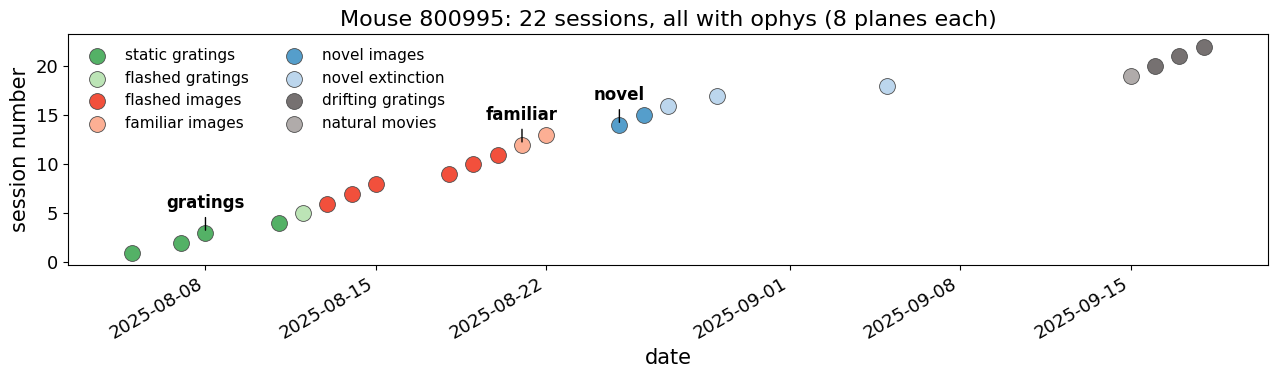

In [9]:
fig, ax = plt.subplots(figsize=(13, 4))

# One scatter call per category, so each gets its own legend entry.
for category, color in stimulus_colors.items():
    in_category = (session_categories == category).values
    if not in_category.any():
        continue
    ax.scatter(session_dates[in_category], mouse_sessions.loc[in_category, 'session_number'],
               s=130, color=color, edgecolor='0.3', linewidth=0.6, label=category, zorder=3)

# Mark the three sessions this notebook analyzes, so their place in the sequence is clear.
for session, label in [(gratings_session, 'gratings'),
                       (familiar_session, 'familiar'),
                       (novel_session, 'novel')]:
    session_date = pd.to_datetime(session['session_date'])
    ax.annotate(label, xy=(session_date, session['session_number']),
                xytext=(0, 18), textcoords='offset points',
                ha='center', fontsize=12, fontweight='bold',
                arrowprops=dict(arrowstyle='-', lw=1))

n_sessions = len(mouse_sessions)
min_planes = mouse_sessions['n_planes'].min()

ax.set_xlabel('date')
ax.set_ylabel('session number')
ax.set_title(f'Mouse {mouse}: {n_sessions} sessions, all with ophys '
             f'({min_planes} planes each)')
ax.legend(frameon=False, loc='upper left', fontsize=11, ncol=2)
ax.margins(0.06)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Part 2: What is in a session, and what conditions it gives you</h2>

Everything for one session — neural activity, behavior, stimulus, ROI masks — is in a single NWB
file. Opening one is a couple of lines; the useful question is **what the file tells you happened
during the experiment**, and therefore what you can compare.

So as we go through the file, we are building an inventory of experimental conditions:

| What we pull out | The conditions it gives you |
| --- | --- |
| 8 imaging planes | depth — superficial vs deep, layer 1 through upper layer 5 |
| dF/F per neuron | the activity being explained |
| `stimulus_presentations` | which image or orientation was on screen, and which flashes were changes or omissions |
| `trials` | trial outcome — hit, miss, false alarm — and reward delivery |
| `events` | licks, rewards and changes as instants, for aligning |
| `intervals` | session blocks: gray screen, task, movie |

Each of those is a way of splitting the neurons' activity into groups you can contrast. The rest of
the notebook does exactly that, with cell type as one more grouping.

</div>

In [10]:
# Each session's NWB store lives in a folder named by the metadata table's `name`
# column, inside the dataset mount.
dataset_dir = os.path.join(data_dir, 'Visual-Learning-SWDB')
session_dir = os.path.join(dataset_dir, gratings_session['name'])

# One store per session directory. Match on 'nwb' to catch both forms it can take --
# a .nwb file or a .nwb.zarr directory -- and exclude the .json provenance sidecars
# that ship alongside it. pynwb.read_nwb opens either form.
nwb_files = [path for path in os.listdir(session_dir)
             if 'nwb' in path and not path.endswith('.json')]
assert len(nwb_files) == 1, f'expected one NWB store, found {len(nwb_files)}'

gratings_nwb = pynwb.read_nwb(os.path.join(session_dir, nwb_files[0]))

# Confirm what animal and preparation this is before analyzing anything from it.
session_type = gratings_session['session_type']
session_date = gratings_session['session_date']

print('genotype   :', gratings_nwb.subject.genotype)
print('session    :', session_type, 'on', session_date)

ValueError: Unable to read file: '/data/Visual-Learning-SWDB/multiplane-ophys_800995_2025-08-08_12-49-42_processed_2026-08-19_00-56-19/multiplane-ophys_800995_2025-08-08_12-49-42.nwb.zarr'. The file is not recognized as an HDF5 NWB file. If you are trying to read a Zarr file, please install hdmf-zarr using: pip install hdmf-zarr

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

The file's top-level containers are the inventory. What matters for this dataset is which one holds
what:

| container | in this file |
| --- | --- |
| `processing` | the 8 imaging planes (one group each), plus `running` |
| `intervals` | `trials`, `stimulus_presentations`, and a flat `intervals` index — things with a duration |
| `events` | licks, rewards and image changes — things that happen at an instant |
| `acquisition` | raw running-wheel voltages |
| `stimulus` | empty here |

</div>

In [ ]:
print('processing :', list(gratings_nwb.processing.keys()))
print('intervals  :', list(gratings_nwb.intervals.keys()))
print('events     :', list(gratings_nwb.events.keys()))
print('acquisition:', list(gratings_nwb.acquisition.keys()))
print('stimulus   :', list(gratings_nwb.stimulus.keys()))

processing : ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7', 'running']
intervals  : ['intervals', 'stimulus_presentations', 'trials']
events     : ['events']
acquisition: ['v_in', 'v_sig']
stimulus   : []


In [ ]:
# Each imaging plane holds several versions of the activity, plus the segmentation.
print('inside one plane group:', list(gratings_nwb.processing['VISp_2'].data_interfaces.keys()))

# The ROI table sits under image_segmentation and has one row per segmented ROI.
gratings_example_roi_table = (gratings_nwb.processing['VISp_2']['image_segmentation']
                              .plane_segmentations['roi_table'].to_dataframe())

print('ROI table:', gratings_example_roi_table.shape)
print('columns  :', gratings_example_roi_table.columns.tolist())

inside one plane group: ['dff_timeseries', 'event_timeseries', 'image_segmentation', 'images', 'neuropil_corrected_timeseries', 'neuropil_fluorescence_timeseries', 'raw_timeseries']
ROI table: (83, 11)
columns  : ['is_soma', 'soma_probability', 'is_dendrite', 'dendrite_probability', 'cellpose_soma_probability', 'aspect_ratio', 'compact', 'solidity', 'radius', 'footprint', 'image_mask']


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>One plane's activity</h3>

`dff_timeseries` is the signal to use for most analyses. **&Delta;F/F** is fluorescence change
relative to each neuron's own baseline, which makes a bright neuron and a dim one comparable — both
read out as a *fractional* change. (`event_timeseries`, deconvolved events, is also in each plane
group if you want sparser estimates of spiking.)

Two dataset-specific things to know, both of which matter later:

- The activity array is `(frames, ROIs)`, and **each plane has its own timestamps** — the mesoscope
  visits planes in sequence rather than imaging them at once.
- **Depth comes from the metadata table**, via the `imaging_depths` column paired with `plane_names`.
  The NWB has the same number buried in a free-text `location` string (`'Structure: VISp Depth: 160'`);
  we print it below for comparison, but a parsed column beats parsing a string.

Depth is the first experimental condition available here: these 8 planes span roughly layer 1 to
upper layer 5.

</div>

In [ ]:
plane = 'VISp_2'

# The dF/F trace for every ROI in this one plane.
dff_series = gratings_nwb.processing[plane]['dff_timeseries']['dff_timeseries']
plane_dff = dff_series.data[:]                    # (frames, ROIs) -- [:] actually reads it
plane_timestamps = dff_series.timestamps[:]       # seconds, on the same clock as behavior

# Depth per plane, from the v2 metadata columns. imaging_depths is in plane_names order,
# so pairing them positionally gives plane name -> depth in microns.
gratings_plane_names = ast.literal_eval(gratings_session['plane_names'])
gratings_imaging_depths = ast.literal_eval(gratings_session['imaging_depths'])
gratings_depth_of_plane = dict(zip(gratings_plane_names, gratings_imaging_depths))

# The same information as free text on the NWB's ImagingPlane, for comparison.
imaging_plane = (gratings_nwb.processing[plane]['image_segmentation']
                 .plane_segmentations['roi_table'].imaging_plane)

frame_rate = 1 / np.median(np.diff(plane_timestamps))
duration_min = plane_timestamps[-1] / 60

print(f'{plane}: dff {plane_dff.shape} (frames, ROIs) '
      f'at {gratings_depth_of_plane[plane]} um')
print(f'  NWB location string: {imaging_plane.location!r}')
print(f'  frame rate         : {frame_rate:.2f} Hz')
print(f'  session duration   : {duration_min:.1f} min')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Before any processing, look at the signal itself. This is one neuron's &Delta;F/F for the whole
session -- a mostly flat baseline with occasional large transients, which is what a calcium trace
looks like. Everything later in the notebook is built out of traces like this one, so it is worth
seeing one before it disappears into a heatmap.

The dashed lines mark where the session's coarse blocks start, so the trace can be read against the
structure of the experiment.

</div>

In [ ]:
# The first look at the actual signal: one neuron's dF/F across the whole session.

# Which neuron to show? Not the one with the biggest standard deviation -- that picks a
# cell whose signal is dominated by slow drift over the session, so the transients we
# actually want to see are squashed flat. Instead ask for a neuron with big, clean
# events on a steady baseline, using two numbers per ROI:
#
#   noise  -- the typical frame-to-frame wobble, measured robustly so a few large
#             transients do not inflate it
#   wander -- how much the trace moves around on a MINUTE timescale (slow drift)
#
# Keep the ROIs whose slow wander is small compared with their own noise, then take the
# one with the tallest events relative to its noise.
median_per_roi = np.median(plane_dff, axis=0)
noise_per_roi = np.median(np.abs(plane_dff - median_per_roi), axis=0) * 1.4826

# Average the trace in one-minute bins; how much those bin values move is the drift.
frames_per_minute = int(60 / np.median(np.diff(plane_timestamps)))
n_whole_minutes = plane_dff.shape[0] // frames_per_minute
minute_bins = plane_dff[:n_whole_minutes * frames_per_minute]
minute_bins = minute_bins.reshape(n_whole_minutes, frames_per_minute, -1).mean(axis=1)
wander_per_roi = minute_bins.std(axis=0)

event_height = np.percentile(plane_dff, 99, axis=0) - median_per_roi

# Score only the steady ROIs; -inf parks the drifty ones at the bottom of the argmax.
is_steady = wander_per_roi < 0.5 * noise_per_roi
score = np.where(is_steady, event_height / noise_per_roi, -np.inf)
example_column = int(np.argmax(score))

print(f'{is_steady.sum()} of {len(is_steady)} ROIs have a steady baseline; '
      f'showing ROI {example_column}')

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(plane_timestamps / 60, plane_dff[:, example_column], linewidth=0.5, color='black')

# The session's coarse blocks are rows of the flat `intervals` table tagged
# interval_type == 'epoch'. We only need their start times here; that table gets a
# proper introduction in the next section.
session_intervals = gratings_nwb.intervals['intervals'].to_dataframe()
epoch_rows = session_intervals[session_intervals['interval_type'] == 'epoch']

for epoch_start in epoch_rows['start_time']:
    ax.axvline(epoch_start / 60, color='tab:blue', linestyle='--', linewidth=1)

ax.set_xlabel('Time from session start (min)')
ax.set_ylabel(r'$\Delta$F/F')
# Name the ROI the way the rest of the notebook does -- roi_id is unambiguous, whereas a
# bare column number means one thing within a plane and another in the stacked matrix.
example_roi_id = f'{plane}_{example_column:04d}'

ax.set_title(f'{example_roi_id}: whole session '
             f'(dashed lines: starts of the session epochs)')
fig.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>All 8 planes together, and naming every ROI</h3>

We want one activity matrix for the session &mdash; `(frames, neurons)` with all 8 planes side by side
&mdash; plus a table with one row per column of that matrix.

The important decision is in that table. Each plane's ROI table is tied to its activity array by
**row order alone** (the `id` column is all zeros here). Rather than carry that fragile positional
relationship around, we turn position into a **name**, once, in the format the coregistration table
uses:

| Column | Built from | Example |
| --- | --- | --- |
| `roi_id` | plane name + row index, zero-padded | `VISp_0_0010` |
| `unique_roi_id` | `<mouse>_<date>_` + `roi_id` | `800995_2025-08-21_VISp_0_0010` |

From here on every join is **on a string key**, not an array offset — which is what makes it safe to
subset in any order, since each row carries its own identity.

We also add two integer columns, and it is worth being clear about the difference because they are
easy to confuse:

| Column | Points into |
| --- | --- |
| `column_in_dff` | the session's activity matrix `<session>_dff_all` |
| `plane_roi_index` | that plane's own NWB ROI table, needed for the masks in Part 4 |

There is exactly **one** activity matrix per session and **one** column index into it. `column_in_dff`
is assigned here and never reassigned, so it means the same thing in this table and in every subset of
it we make later.

<h4>The 8 planes do not share a time base</h4>

The planes are imaged in **pairs**: the two planes of a pair share timestamps exactly, and the pairs
are staggered. How large the stagger is depends on how the scope was configured, so **measure it for
your session** rather than computing it from the frame rate — the cell below does, by subtracting one
plane's timestamps from another's. It comes out at tens of milliseconds, an appreciable fraction of a
frame interval and not a rounding error.

**The rule that follows: whenever you convert a time into a frame index, use the timestamps of the
plane that neuron belongs to.** This is why `align_to_changes` in Part 4 loops over planes instead of
indexing the whole matrix at once — the concatenated array is fine to store, but you slice it per
plane. We do not interpolate onto a common clock, which would invent values that were never measured.
(A whole-session heatmap is the one place the offset is safely ignorable.)

</div>

In [ ]:
# The imaging planes, from the metadata table rather than assumed to be VISp_0..VISp_7.
# Note the session prefix: each session gets its own list, because they can differ.
gratings_plane_names = ast.literal_eval(gratings_session['plane_names'])

# session_key is how the coregistration table names a session: <mouse>_<date>. We build
# it here because the ROI id strings below have to match that naming exactly.
session_date = gratings_session['session_date']
gratings_session_key = f'{mouse}_{session_date}'

print('planes:', gratings_plane_names)
print('session_key:', gratings_session_key)

Read each plane in turn. Three things come out of every plane: its dF/F matrix, its own
timestamp vector, and its ROI table. We collect them in lists and combine them afterwards.

In [ ]:
dff_per_plane = []
roi_tables_per_plane = []
gratings_timestamps = {}          # one timestamp array per plane, not one shared vector

for plane in gratings_plane_names:
    dff_series = gratings_nwb.processing[plane]['dff_timeseries']['dff_timeseries']
    plane_dff = np.asarray(dff_series.data[:])
    gratings_timestamps[plane] = np.asarray(dff_series.timestamps[:])

    plane_segmentation = (gratings_nwb.processing[plane]['image_segmentation']
                          .plane_segmentations['roi_table'])
    roi_table = plane_segmentation.to_dataframe()

    # THE positional assumption, asserted once and then never relied on again:
    # row i of the ROI table is column i of this plane's dF/F matrix.
    assert len(roi_table) == plane_dff.shape[1], (
        f'{plane}: ROI table has {len(roi_table)} rows but dff has '
        f'{plane_dff.shape[1]} columns -- cannot assign ROI ids')

    dff_per_plane.append(plane_dff)
    roi_tables_per_plane.append(roi_table)

print('planes read:', len(dff_per_plane))

Now turn each plane's ROI table into rows we can join on later. The coregistration table
names ROIs by position within a plane, so we build the same id strings here: that string
is the only thing that links an activity column to a cell type.

In [ ]:
roi_rows_per_plane = []

for plane, roi_table in zip(gratings_plane_names, roi_tables_per_plane):
    # Position within the plane, which is what the id strings encode.
    roi_index = np.arange(len(roi_table))

    roi_id = [f'{plane}_{i:04d}' for i in roi_index]
    unique_roi_id = [f'{gratings_session_key}_{name}' for name in roi_id]

    roi_rows_per_plane.append(pd.DataFrame({
        'plane': plane,
        'imaging_depth_um': gratings_depth_of_plane[plane],
        'roi_id': roi_id,
        'unique_roi_id': unique_roi_id,
        'plane_roi_index': roi_index,
        'is_soma': roi_table['is_soma'].values.astype(bool),
    }))

print('ROI tables built:', len(roi_rows_per_plane))

Concatenate the planes into one activity matrix for the session, with one table row per
column of that matrix. `column_in_dff` is the bookkeeping that keeps the two aligned.

In [ ]:
# Concatenate along the neuron axis: (frames, all ROIs in the session).
# NOTE: this stacks planes that were sampled at slightly DIFFERENT times. That is fine
# for storage, but it means row f of this array is not one instant -- see below.
gratings_dff_all = np.concatenate(dff_per_plane, axis=1)

gratings_roi_table = pd.concat(roi_rows_per_plane, ignore_index=True)
gratings_roi_table['column_in_dff'] = np.arange(len(gratings_roi_table))

assert gratings_roi_table['unique_roi_id'].is_unique, 'unique_roi_id is not unique'

n_soma = gratings_roi_table['is_soma'].sum()
n_roi = len(gratings_roi_table)

print('dff (frames, ROIs):', gratings_dff_all.shape)
print(f'soma ROIs: {n_soma} of {n_roi}')

gratings_roi_table.head(3)

The eight planes do **not** share a clock. The mesoscope visits them in sequence, so frame
`f` of one plane was acquired slightly before frame `f` of another. This matters as soon as
you align activity to an event, so measure the offsets rather than assuming them: subtract
one plane's timestamp array from another's, elementwise.

In [ ]:
reference_plane = gratings_plane_names[0]
reference_timestamps = gratings_timestamps[reference_plane]

frame_interval = np.median(np.diff(reference_timestamps))
frame_rate = 1 / frame_interval

print(f'frame interval: {frame_interval * 1000:.2f} ms ({frame_rate:.2f} Hz)')
print(f'offset from {reference_plane}, over all {len(reference_timestamps)} frames:')

for plane in gratings_plane_names:
    # Elementwise: frame f of this plane vs frame f of the reference plane.
    offset_ms = (gratings_timestamps[plane] - reference_timestamps) * 1000
    median_offset = np.median(offset_ms)
    print(f'  {plane}: median {median_offset:7.2f} ms '
          f'(range {offset_ms.min():7.2f} to {offset_ms.max():7.2f})')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The behavior tables: intervals vs events</h3>

All the behavior lives in tables that are **on the same clock as the imaging timestamps**, which is
what makes alignment possible at all. They come in two flavours, and the distinction is simply
whether the thing being described has a duration:

- **`intervals`** tables have `start_time` and `stop_time` — a trial, a flash, an epoch.
- **`events`** tables have a single `timestamp` — a lick, a reward delivery, an image change.

The same occurrence can appear in both: an image change is the boundary of a stimulus presentation
(interval) *and* an instant (event). Use whichever matches what you are aligning to.

<h4>Which tables to use</h4>

**`intervals` and `events` are the core tables.** Between them they hold all the behavior and
stimulus information in the session, and everything else is derived from them.

`stimulus_presentations` and `trials` are those derived tables. They add columns *computed* from
`intervals` and `events` — trial outcome flags, `change_time`, `response_latency`, `is_change` — which
can be genuinely useful. They exist because they are **deliberately designed to mirror the tables in
the Visual Behavior Ophys dataset**: if you want to analyze both datasets together, or reuse code
written against VBO, these are the tables that will make that work.

**If you are new to this dataset, start with `intervals` and `events`.** Two reasons. They are more
intuitive — one flat table of things-with-duration and one of things-that-happen. And they follow the
[**HED (Hierarchical Event Descriptor)**](https://www.hed-resources.org/) schema, which annotates
every row with standardized tags describing what it *is*, rather than leaving you to infer meaning
from a column name.

That annotation is in the `HED` column, and it is populated on every row:

```
Experimental-trial, Non-target, Incorrect-action, Label/false_alarm_trial
Sensory-event, Visual-presentation, (Image, Label/im061), Target
Time-block, Pause, Label/spontaneous
```

Because the vocabulary is a published standard rather than a local convention, those tags are both
human-readable and machine-readable — you can select "all target stimulus events" across datasets
that share the schema without knowing each one's column names. `stimulus_presentations` and `trials`
carry `HED` too, but the flat `intervals` table has the richest vocabulary (29 distinct tag strings in
this session, against 17 and 6), because it is the only one that covers epochs, response windows,
trials and flashes in the same place. The `events` table encodes its equivalent differently: its
categorical columns come with `meanings_tables` giving the value definitions.

<h4>The four tables in `intervals`</h4>

| table | one row per | use it for |
| --- | --- | --- |
| `intervals` | *any* interval | the flat index of everything: epochs, trials, response windows, flashes |
| `trials` | behavioral trial | trial outcome, `change_time`, reward — the widest table, 27 columns |
| `stimulus_presentations` | stimulus flash | what was on screen when, and which flash was a change |
| `natural_movie_one_presentations` | movie frame | the appended natural-movie block, when a session has one |

The flat `intervals` table is the quickest way to see the overall structure of a session. Every
interval is there, distinguished by an `interval_type` column, with foreign keys (`trials_id`,
`stimulus_presentations_id`) pointing back into the specific tables — including the `epoch` rows that
mark the gray-screen and task blocks, which are not in the other tables at all.

</div>

In [ ]:
gratings_trials = gratings_nwb.intervals['trials'].to_dataframe()
gratings_stimulus = gratings_nwb.intervals['stimulus_presentations'].to_dataframe()
gratings_all_intervals = gratings_nwb.intervals['intervals'].to_dataframe()
gratings_events = gratings_nwb.events['events'].to_dataframe()

for name, table in [('trials', gratings_trials),
                    ('stimulus_presentations', gratings_stimulus),
                    ('intervals', gratings_all_intervals),
                    ('events', gratings_events)]:
    print(f'{name:24s} {table.shape[0]:>5} rows x {table.shape[1]:>2} columns')

trials                    1314 rows x 27 columns
stimulus_presentations     198 rows x 13 columns
intervals                 1734 rows x  8 columns
events                    3295 rows x 11 columns


In [ ]:
# The flat intervals table is the fastest way to see a session's structure:
# every interval, tagged by what kind it is.
print(gratings_all_intervals['interval_type'].value_counts().to_string())
print()

# The epoch rows are the session's coarse blocks -- only in this table.
gratings_all_intervals[gratings_all_intervals['interval_type'] == 'epoch']

interval_type
trial                    1314
response_window           219
stimulus_presentation     198
epoch                       3



,start_time,stop_time,interval_type,label,trials_id,stimulus_presentations_id,natural_movie_one_presentations_id,HED
id,,,,,,,,
0,0.00000,38.62081,epoch,spontaneous,-1,-1,-1,"Time-block, Pause, Label/spontaneous"
1,38.62081,3643.57947,epoch,change_detection,-1,-1,-1,"Time-block, Experiment-procedure, Label/change..."
1733,3643.57947,3660.22663,epoch,spontaneous,-1,-1,-1,"Time-block, Pause, Label/spontaneous"


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4>`trials` — one row per behavioral trial</h4>

The widest table. Every trial gets an outcome, and the outcome columns are **booleans, one per
category**, rather than a single label — so you select a condition by masking on the flag you want.

| column | what it is |
| --- | --- |
| `start_time`, `stop_time` | trial bounds, seconds on the session clock |
| `go` / `catch` | the image *did* change / a change time was drawn but the image did not change |
| `hit` / `miss` | on a go trial: licked in the response window / did not |
| `false_alarm` / `correct_reject` | on a catch trial: licked anyway / correctly withheld |
| `aborted` | licked before the scheduled change — usually the **most common** outcome |
| `auto_rewarded` | reward given without requiring a lick (early trials) |
| `warm_up` | the easier trials at the start of a session |
| `change_time`, `change_frame` | **when the image changed** — the anchor for everything in Part 4 |
| `initial_image_name`, `change_image_name` | what was on screen before and after the change |
| `initial_orientation`, `change_orientation` | the same for grating sessions, in degrees |
| `response_time`, `response_latency` | when the mouse licked, and how long after the change |
| `reward_time`, `reward_volume` | when reward was delivered, and how much (mL) |
| `change_window_*`, `response_window_*` | the windows the task used to score the trial |
| `epoch_name` | which session block this trial belongs to |

Note how the outcome counts break down below: aborted trials dominate, which is normal — the mouse
licks impulsively and the trial restarts. Filter to `go` or `catch` before computing performance.

</div>

In [ ]:
# Outcome counts. These are boolean columns, so summing gives the trial count per category.
outcome_columns = ['go', 'catch', 'auto_rewarded', 'aborted',
                   'hit', 'miss', 'false_alarm', 'correct_reject', 'warm_up']
print(gratings_trials[outcome_columns].sum().to_string())

# A few go trials, showing the columns Part 4 uses.
gratings_trials.loc[gratings_trials['go'],
                    ['start_time', 'change_time', 'change_image_name', 'change_orientation',
                     'hit', 'response_latency', 'reward_time', 'reward_volume']].head()

go                 182
catch              165
auto_rewarded       80
aborted           1095
hit                 67
miss               115
false_alarm          3
correct_reject      19
warm_up              5


,start_time,change_time,change_image_name,change_orientation,hit,response_latency,reward_time,reward_volume
id,,,,,,,,
72,185.14247,188.791158,gratings_90,90.0,False,0.988492,NaN,0.00
80,199.58780,201.952088,gratings_180,180.0,True,0.521442,202.47353,0.01
117,255.40080,257.731728,gratings_90,90.0,True,0.738282,258.47001,0.01
146,311.08037,314.462158,gratings_0,0.0,True,0.454742,314.91690,0.01
147,318.93689,322.118548,gratings_90,90.0,True,0.154442,322.27299,0.01


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4>`stimulus_presentations` — one row per flash</h4>

What was on screen, and when. This is the table to use when you want to know the stimulus rather than
the mouse's behavior.

| column | what it is |
| --- | --- |
| `start_time`, `stop_time` | when this flash was on screen |
| `image_name` | which image, or the grating identity (`gratings_90`, …) |
| `orientation` | grating orientation in degrees; `NaN` for natural images |
| `is_change` | **True if the identity changed at this flash** — the same instants as `trials.change_time` |
| `omitted` | True for a deliberately skipped flash (only in `OPHYS_*` sessions) |
| `lick_latency` | time to the next lick, if any |
| `trials_id` | which trial this flash belongs to — the join key back to `trials` |
| `epoch_name` | which session block |

`is_change` and `omitted` are the two columns most analyses turn on. Note that `omitted` is all
`False` in a `TRAINING_` session — flash omissions were only introduced in the post-criterion
`OPHYS_` sessions. (Both kinds of session have imaging; the difference is in the stimulus design,
not the recording.)

</div>

In [ ]:
print('flashes            :', len(gratings_stimulus))
print('  changes (is_change):', int(gratings_stimulus['is_change'].sum()))
print('  omitted            :', int(gratings_stimulus['omitted'].sum()))
print('  stimuli present    :', sorted(gratings_stimulus['image_name'].unique()))

gratings_stimulus[['start_time', 'stop_time', 'image_name', 'orientation',
                   'is_change', 'omitted', 'trials_id']].head()

flashes            : 198
  changes (is_change): 197
  omitted            : 0
  stimuli present    : ['gratings_0', 'gratings_180', 'gratings_270', 'gratings_90']


,start_time,stop_time,image_name,orientation,is_change,omitted,trials_id
id,,,,,,,
0,38.666508,38.916508,gratings_90,90.0,False,False,0
1,49.342048,49.342048,gratings_0,0.0,True,False,5
2,71.794008,71.794008,gratings_90,90.0,True,False,15
3,83.386978,83.386978,gratings_180,180.0,True,False,19
4,118.332678,170.125668,gratings_270,270.0,True,False,36


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

The claim that behavior and imaging share one clock is easy to assert and easy to check. Here is the
same example neuron's trace with the image-change times drawn on top, once for the whole session and
once over a 60 s stretch where the individual events are separable. The trace comes from the imaging
data and the red lines come from the stimulus table, so if the clocks did not agree the lines would
land nowhere in particular.

</div>

In [ ]:
def plot_trace_with_changes(ax, times, trace, change_times, start, stop):
    """One neuron's trace between start and stop, with change times as red lines."""
    in_view = (times >= start) & (times <= stop)
    ax.plot(times[in_view], trace[in_view], linewidth=0.6, color='black')

    for change_time in change_times[(change_times >= start) & (change_times <= stop)]:
        ax.axvline(change_time, color='tab:red', linewidth=0.8, alpha=0.7)

    ax.set_xlim(start, stop)
    ax.set_ylabel(r'$\Delta$F/F')


# Work from the full activity matrix plus a column index out of the ROI table, rather
# than from the single-plane arrays -- the loop above reused those variable names.
example_plane = 'VISp_2'
plane_columns = gratings_roi_table.loc[gratings_roi_table['plane'] == example_plane,
                                       'column_in_dff'].values

# Same steady-baseline rule as the earlier trace plot, so this is the same neuron.
plane_traces = gratings_dff_all[:, plane_columns]
plane_times = gratings_timestamps[example_plane]

median_per_roi = np.median(plane_traces, axis=0)
noise_per_roi = np.median(np.abs(plane_traces - median_per_roi), axis=0) * 1.4826

frames_per_minute = int(60 / np.median(np.diff(plane_times)))
n_whole_minutes = plane_traces.shape[0] // frames_per_minute
minute_bins = plane_traces[:n_whole_minutes * frames_per_minute]
minute_bins = minute_bins.reshape(n_whole_minutes, frames_per_minute, -1).mean(axis=1)
wander_per_roi = minute_bins.std(axis=0)

event_height = np.percentile(plane_traces, 99, axis=0) - median_per_roi
is_steady = wander_per_roi < 0.5 * noise_per_roi
score = np.where(is_steady, event_height / noise_per_roi, -np.inf)

example_column = plane_columns[int(np.argmax(score))]

# Same ROI as the earlier plot. Take its roi_id from the table rather than rebuilding the
# string, so the two plots provably name the same neuron.
example_roi_id = gratings_roi_table.loc[
    gratings_roi_table['column_in_dff'] == example_column, 'roi_id'].iloc[0]
example_trace = gratings_dff_all[:, example_column]
example_times = gratings_timestamps[example_plane]

# The change times, read from the stimulus table rather than the imaging data.
change_times = gratings_stimulus.loc[gratings_stimulus['is_change'], 'start_time'].values
zoom_centre = change_times[len(change_times) // 2]

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
plot_trace_with_changes(axes[0], example_times, example_trace, change_times,
                        example_times[0], example_times[-1])
plot_trace_with_changes(axes[1], example_times, example_trace, change_times,
                        zoom_centre - 20, zoom_centre + 40)

axes[0].set_title(f'{example_roi_id}: whole session, '
                  f'red lines = image changes')
axes[1].set_title('the same trace over 60 s')
axes[1].set_xlabel('Time from session start (s)')
fig.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4>`events` — one row per instant</h4>

Everything that happens at a moment rather than over a window. One table holds all of it, with
`event_type` saying which kind, and the remaining columns describing it along **independent
dimensions** — so a lick is characterized by its classification *and* its position in a bout, rather
than by one combined label.

| column | what it is |
| --- | --- |
| `timestamp` | when it happened, session clock |
| `event_type` | `lick`, `reward`, or `image_change` |
| `lick_classification` | for licks: `hit`, `false_alarm`, `abort`, `consumption`, `spontaneous`, `early`, `late` |
| `lick_bouts` | `bout_start` or `within_bout` — licks come in bursts, and often you only want the first |
| `reward_type` | `earned` (mouse licked for it) or `auto_reward` |
| `reward_volume` | mL delivered |
| `image_name`, `orientation` | what was on screen for change events |
| `trials_id`, `stimulus_presentations_id` | join keys back into the interval tables (`-1` = not applicable) |
| `frame` | the stimulus frame index |

Two things this table gives you that `trials` does not: **every individual lick** (a trial records
only the first response), and licks that fall outside any trial. `lick_bouts` is the practical one —
filtering to `bout_start` turns 3,000 licks into ~1,100 distinct lick events.

</div>

In [ ]:
print('event types:')
print(gratings_events['event_type'].value_counts().to_string())
print()
print('lick classifications:')
print(gratings_events['lick_classification'].value_counts().to_string())
print()

# Licks come in bouts; bout_start is usually what you want as "a lick happened here".
lick_events = gratings_events[gratings_events['event_type'] == 'lick']
n_bout_starts = (lick_events['lick_bouts'] == 'bout_start').sum()
print(f'{len(lick_events)} licks, of which {n_bout_starts} start a bout')

gratings_events[['timestamp', 'event_type', 'lick_classification', 'lick_bouts',
                 'reward_type', 'trials_id']].head()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Part 3: Align ophys to transcriptomics</h2>

This is the first of the two alignments, and the reason the dataset exists. Everything we plot
afterwards depends on getting it right.

The link is made by a **coregistration table**, produced by matching the imaged neurons to cells in
the post-hoc HCR volume.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The three ID systems</h3>

This is the part that trips people up. The imaging and the transcriptomics are two separate
measurements of the same tissue, and connecting them takes an intermediate step.

The physical chain is:

```
imaging plane  -->  structural stack  -->  HCR volume
  (one FOV,           (one z-stack of        (thin sections,
   one session)        the same volume)       gene expression)
```

Each imaging plane is registered into a **structural stack** — a high-resolution z-stack of the
same volume — and the structural stack is registered to the **HCR volume**. Going straight from a
2-photon plane to a tissue section is not tractable; the stack is the common reference frame that
makes both registrations possible. The stack is a step in the *pipeline*, not something you index
into here directly, but it is not bookkeeping to ignore either: the stack cell is the entity that
unifies the two modalities, and the column that names it is **`resolved_cz_stack_id`** (see below
for why the resolved one and not `cz_stack_id`).

The three identifiers you actually use:

| ID | Scope | What it identifies |
| --- | --- | --- |
| `unique_roi_id` | **one session, one plane** | one ROI mask, as segmented in this plane on this day |
| `unique_roicat_id` | **all sessions of one mouse** | a neuron, tracked across days |
| `hcr_id` | the mouse's HCR volume | the transcriptomic cell |

Why two IDs on the imaging side? Because a neuron imaged on Monday and again on Tuesday is the
*same cell* but a *different row* in each day's data. `unique_roi_id` is the row; `unique_roicat_id`
is the cell.

The coregistration table carries all three on the same row, which is what makes the link possible:

```
unique_roi_id  -->  unique_roicat_id  -->  hcr_id  -->  subclass
 (ROI mask, one       (the neuron,        (HCR cell)   (cell type)
  plane, one day)      across days)
   \_______ coreg id mapping table _______/   \__ HCR AnnData __/
```

Each end has a job: `unique_roi_id` finds the activity data, `unique_roicat_id` tracks a neuron
across sessions (Part 7), and `hcr_id` looks up the cell type.

</div>

In [ ]:
# coreg_path was located in Part 1; read the whole table now. One table per mouse,
# covering every session of that mouse the pipeline succeeded on.
print('reading', os.path.relpath(coreg_path, data_dir))

coreg_table = pd.read_csv(coreg_path, index_col=0)

n_sessions_in_table = coreg_table['session_key'].nunique()
n_neurons_in_table = coreg_table['unique_roicat_id'].nunique()

print(coreg_table.shape, '|', n_sessions_in_table, 'sessions',
      '|', n_neurons_in_table, 'distinct neurons')
print('columns:', coreg_table.columns.tolist())

How many sessions is each neuron detected in? There is one row per (neuron, session), so
count distinct session keys per neuron rather than trusting a flag column.

In [ ]:
sessions_per_neuron = coreg_table.groupby('unique_roicat_id')['session_key'].nunique()

median_sessions = sessions_per_neuron.median()
max_sessions = sessions_per_neuron.max()
n_single_session = (sessions_per_neuron == 1).sum()
n_neurons = len(sessions_per_neuron)

print(f'sessions per neuron: median {median_sessions:.0f}, max {max_sessions}')
print(f'seen in only one session: {n_single_session} of {n_neurons}')

The table carries both the raw z-stack match and the resolved one. `changed` marks the rows
where resolution moved the match, which is the step worth seeing at work.

In [ ]:
n_changed = coreg_table['changed'].sum()
percent_changed = 100 * coreg_table['changed'].mean()

print(f'rows where resolution changed the raw match: {n_changed} of {len(coreg_table)} '
      f'({percent_changed:.1f}%)')

# Both stack columns are shown so you can compare them directly.
coreg_table[['session_key', 'unique_roi_id', 'unique_roicat_id', 'plane_id',
             'cz_stack_id', 'resolved_cz_stack_id', 'changed', 'hcr_id']].head(5)

In [ ]:
# Why resolved_cz_stack_id and not cz_stack_id? Check the consistency of each column
# WITHIN each neuron: every ROI sharing a unique_roicat_id is the same physical cell, so
# they must all point at the same z-stack cell.
for column in ['cz_stack_id', 'resolved_cz_stack_id']:
    has_match = coreg_table[coreg_table[column] > 0]
    ids_per_neuron = has_match.groupby('unique_roicat_id')[column].nunique()

    n_inconsistent = (ids_per_neuron > 1).sum()
    print(f'{column:24s} neurons mapping to >1 stack cell: '
          f'{n_inconsistent:>4} of {len(ids_per_neuron)}')

# And the consequence for anything downstream: does the column contain every typed cell?
typed = coreg_table[coreg_table['hcr_id'] > 0]
print()
for column in ['cz_stack_id', 'resolved_cz_stack_id']:
    n_missing_stack_id = (typed[column] <= 0).sum()
    print(f'{column:24s} rows with an hcr_id but no stack id: '
          f'{n_missing_stack_id:>5} of {len(typed)}')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>What is in the coregistration table</h3>

One row per **coregistered ROI per session**. Note this is a *subset* of each session's segmented
ROIs — the pipeline only carries forward ROIs it tracked — and rows are present whether or not the
match to a transcriptomic cell succeeded.

| Column | Scope | Meaning |
| --- | --- | --- |
| `session_key` | — | `<mouse>_<date>`, which session this row belongs to |
| `unique_roi_id` | one session | one ROI mask on one day |
| `unique_roicat_id` | one mouse | the **neuron**, tracked across sessions by ROICaT |
| `plane_id` | one session | which imaging plane, `VISp_0`-`VISp_7` |
| `hcr_id` | HCR volume | the transcriptomic cell — **the key into the AnnData** |
| `resolved_cz_stack_id` | structural stack | the z-stack cell that links the two modalities — **use this one** |
| `cz_stack_id` | structural stack | the raw per-session match, before ambiguities are resolved |
| `matched` | one mouse | flags neurons tracked across more than one session |
| `max_iou`, `changed`, `undecided` | — | bookkeeping from the stack-matching step |

Four things worth knowing before you join:

- **Unmatched entries are `-1`, not empty.** Convert them to `NaN` first, or every failed ROI joins
  to whatever cell happens to sit at id `-1`.
- **Not every session is in this table.** Some sessions fail the pipeline, so a session with a
  perfectly good NWB may have zero coregistration rows. The cell above counts them.
- **Use `resolved_cz_stack_id`, not `cz_stack_id`.** The raw column matches each ROI to a stack cell
  by spatial overlap independently in each session, which leaves ambiguities — the same neuron
  matched to different stack cells on different days. Resolution uses `unique_roicat_id` to settle
  them: all ROIs of one neuron must map to one stack cell. After resolution no neuron maps to more
  than one stack cell, and **every row with an `hcr_id` has a valid `resolved_cz_stack_id`** — which
  is not true of the raw column, so filtering on it discards real matches.
- **`matched` is about tracking, not cell types.** It marks neurons seen in more than one session,
  which is what Part 7 needs. It is *not* a quality filter on the transcriptomic match — 519 neurons
  with `matched == False` carry a valid `hcr_id`.

<h4>Watch the scope of every id</h4>

`unique_roicat_id` is unique **within a mouse only** — 1,722 of these ids occur in more than one
animal. So group by **`(subject_id, unique_roicat_id)`**, never by `unique_roicat_id` alone. Getting
this wrong raises no error; it just returns a wrong answer (2,453 neurons instead of 7,882).

Same care for the others: `unique_roi_id` is scoped to one session, and `plane_id` is **not** depth
order — `VISp_0` is not the most superficial plane. Sort by `imaging_depths` when you mean depth.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The two ID scopes, and why both exist</h3>

This is the distinction to hold onto, because every join in the rest of the notebook depends on it.

- **`unique_roi_id` is one ROI mask, in one imaging plane, in one session.** It names a
  *segmentation result*: this blob of pixels, in this plane, on this day. Segmentation is run
  independently on each session, so a session has exactly one `unique_roi_id` per ROI it found, and
  the same neuron gets a *different* `unique_roi_id` in every session it appears in.
- **`unique_roicat_id` is one neuron, across all sessions of that mouse.** ROICaT matches ROI masks
  across sessions by their shape and position, and assigns each resulting neuron a single identifier
  that is stable across every session of that mouse. It is the unique identifier for a neuron — and
  a neuron detected in only one session still gets one, so having a `unique_roicat_id` does not by
  itself mean the cell was tracked across days.

So the relationship is **many `unique_roi_id` to one `unique_roicat_id`**, and how many varies per
neuron. A neuron detected on 12 of 20 days has 12 rows sharing one `unique_roicat_id`. This is why
Part 7 can track a neuron across days at all, and why the number of sessions a neuron appears in is
itself a data-quality variable.

Note also that `roi_id` is **not comparable between sessions**: `VISp_0_0010` on Monday and
`VISp_0_0010` on Tuesday are unrelated segmentations that happened to land at the same row index.
Only `unique_roicat_id` crosses sessions.

</div>

In [ ]:
# How many sessions does each neuron appear in? One bar per count.
sessions_per_neuron = coreg_table.groupby('unique_roicat_id')['session_key'].nunique()
neurons_per_count = sessions_per_neuron.value_counts().sort_index()

# Numbers for the title, pulled out first so the f-string stays readable.
n_neurons = len(sessions_per_neuron)
n_seen_once = (sessions_per_neuron == 1).sum()
median_sessions = sessions_per_neuron.median()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(neurons_per_count.index, neurons_per_count.values, color='#4C72B0')

# Label the two ends -- the singletons and the best-tracked neurons -- since those are
# the numbers you would actually quote.
for n_sessions in [neurons_per_count.index.min(), neurons_per_count.index.max()]:
    n_at_this_count = neurons_per_count[n_sessions]
    ax.annotate(str(n_at_this_count), xy=(n_sessions, n_at_this_count),
                xytext=(0, 5), textcoords='offset points', ha='center', fontsize=12)

# Integer counts, so force integer ticks rather than letting matplotlib pick halves.
ax.set_xticks(range(0, neurons_per_count.index.max() + 1, 2))
ax.set_xlabel('number of sessions the neuron was detected in')
ax.set_ylabel('number of neurons')
ax.set_title(f'{n_neurons} neurons tracked in mouse {mouse}; '
             f'{n_seen_once} seen once, median {median_sessions:.0f} sessions')
ax.margins(y=0.12)
fig.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The cell types come from the HCR AnnData</h3>

The cell-type labels live in the HCR cell-gene-tables asset, as an **AnnData** object
(`<mouse>_cellxgene_annotated.h5ad`) rather than a CSV. AnnData is the standard container for
single-cell data and it keeps expression and annotations together, which is why we prefer it here:

| Part | Shape | Contents |
| --- | --- | --- |
| `adata.X` | cells x genes | expression, raw spot counts per cell |
| `adata.layers['normalized']` | cells x genes | the same, normalized |
| `adata.obs` | cells x annotations | `class`, `subclass`, `cluster`, QC columns |
| `adata.var` | genes x annotations | `round`, `channel`, `gene` |

Crucially **`adata.obs_names` is the `cell_id`, and `cell_id` is the same identifier as the coreg
table's `hcr_id`.** That single fact is the whole join.

Note that `var_names` are *probe* names like `R5-514-Pvalb` — round, channel, gene — because a gene
is measured in a particular round and channel. The plain gene symbol is in `adata.var['gene']`.

</div>

In [ ]:
# The combined asset holds one folder per mouse, and the folder name carries a date stamp
# we do not want to hardcode. Glob ONE level down -- not recursively, since this asset is
# tens of GB of image data.
hcr_matches = glob.glob(
    os.path.join(data_dir, 'Visual-Learning-Cell-Gene-Tables', '*',
                 f'{mouse}_cellxgene_annotated.h5ad'))

print(f'{len(hcr_matches)} match(es):', [os.path.relpath(p, data_dir) for p in hcr_matches])

adata = ad.read_h5ad(hcr_matches[0])

print(adata)
print('\nobs_names (= cell_id = hcr_id):', adata.obs_names[:5].tolist())

1 match(es): ['Visual-Learning-Cell-Gene-Tables/HCR_800995_unmixed-calibrated_2026-08-20_17-16-54/800995_cellxgene_annotated.h5ad']
AnnData object with n_obs × n_vars = 76143 × 27
    obs: 'class', 'subclass', 'cluster', 'cluster_id', 'total_counts', 'n_genes', 'Slc17a7_counts', 'Gad2_counts'
    var: 'round', 'channel', 'gene'
    uns: 'unmixing'
    layers: 'normalized'

obs_names (= cell_id = hcr_id): ['2', '3', '5', '7', '9']


In [ ]:
# The three annotation columns we care about, coarse to fine.
adata.obs[['class', 'subclass', 'cluster']].value_counts().tail(12)

class       subclass  cluster                 
inhibitory  Lamp5     Lamp5-2 (Npy)               265
            Sst       Sst-5 (Reln/Pdyn/Calb1)     264
                      Sst-3 (Reln/Calb1/Npy)      252
            Vip       Vip-5 (Tac2/Crh/Penk)       249
                      Vip-3 (Tac2/Crh/Calb2)      247
                      Vip-4 (Chat/Calb2/Penk)     202
                      Vip-1 (Penk/Pthlh/Calb2)    195
            Lamp5     Lamp5-3 (Reln/Npy/Ndnf)     185
            Sst       Sst-6 (Hpse/Pdyn/Npy)       156
            Vip       Vip-2 (Cck/Reln/Tac2)       147
            Sst       Sst-4 (Crh/Ndnf/Reln)       144
            Lamp5     Lamp5-1 (Penk/Pdyn/Tac)      91
Name: count, dtype: int64

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Two conventions in `obs` to be aware of before joining:

- `subclass` is `'none'` for every cell that is not one of the four inhibitory subclasses this gene
  panel resolves — excitatory cells and unassigned cells alike. `'none'` is a **string, not a
  missing value**, so `dropna()` will not remove it. We convert it to `NaN` on the way in.
- `class` (`excitatory` / `inhibitory` / `unassigned`) is the coarser label, and it is the honest
  place to look at how many coregistered cells got a confident call at all.

We also have to fix a type mismatch: `hcr_id` is an integer in the coreg table and a string index
in the AnnData. Joins on mismatched types silently produce nothing.

</div>

In [ ]:
cell_types = adata.obs[['class', 'subclass', 'cluster']].copy()
cell_types.columns = ['cell_class', 'subclass', 'cluster_name']

# 'none' / 'unassigned' are placeholder strings, not labels -- make them real missing values.
cell_types['subclass'] = cell_types['subclass'].astype(str).replace('none', np.nan)
cell_types['cluster_name'] = cell_types['cluster_name'].astype(str).replace('unassigned', np.nan)

# Match the coreg table's integer hcr_id so the merge below actually finds anything.
cell_types.index = cell_types.index.astype(np.int64)
cell_types.index.name = 'hcr_id'

print(len(cell_types), 'HCR cells with annotations')
cell_types.tail(3)

76143 HCR cells with annotations


,cell_class,subclass,cluster_name
hcr_id,,,
132094,unassigned,NaN,NaN
132095,unassigned,NaN,NaN
132099,unassigned,NaN,NaN


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Joining, then subsetting — in that order</h3>

Now put the two together. Because we gave every ROI a `unique_roi_id` in the coreg table's own
format back in Part 2, the ophys-to-transcriptomics link is a **string merge**, with no array
arithmetic anywhere:

```
roi_table.unique_roi_id  ==  coreg_table.unique_roi_id     (both '800995_2025-08-21_VISp_0_0010')
                             coreg_table.hcr_id  ==  adata.obs_names
```

We annotate first and subset second, deliberately. Annotating leaves the ROI table the same length
as the activity matrix, so nothing can fall out of step while we are still deciding what to keep.

The joined table gets a new name, `gratings_roi_table_with_types`, instead of being written back over
`gratings_roi_table`. Overwriting is tempting and it is how most notebooks do it, but it means one
variable name refers to a table without cell types above one line and a table with them below it.
Two names, two clearly different things.

</div>

In [ ]:
# Just this session's rows of the coregistration table.
gratings_coreg = coreg_table[coreg_table['session_key'] == gratings_session_key].copy()

# Unmatched entries are -1, not empty. Turn them into NaN BEFORE the join, or every
# failed ROI joins to whatever cell happens to sit at id -1.
for column in ['hcr_id', 'resolved_cz_stack_id']:
    gratings_coreg[column] = gratings_coreg[column].where(gratings_coreg[column] > 0)

print(len(gratings_coreg), 'coregistration rows for this session')

Attach the cell types. `hcr_id` is the key into the HCR cell-type table, so this join is
what turns a coregistered ROI into a typed neuron.

In [ ]:
# validate= makes pandas raise if the key is not unique on the right, which is the check
# you want here: each HCR cell has exactly one label.
gratings_coreg = gratings_coreg.merge(cell_types, left_on='hcr_id', right_index=True,
                                      how='left', validate='many_to_one')

# hcr_id is the key into the AnnData, unique_roicat_id is the key across sessions,
# resolved_cz_stack_id names the z-stack cell (the RESOLVED column, never the raw one),
# and matched flags cells tracked across sessions.
coreg_columns = ['unique_roi_id', 'unique_roicat_id', 'hcr_id', 'resolved_cz_stack_id',
                 'matched', 'cell_class', 'cluster_name', 'subclass']

Now join that onto the session's ROI table. Nothing is dropped, so the table still lines up
row-for-column with the activity matrix; ROIs with no coregistration simply get NaN.

In [ ]:
# Merge on the ID string, NOT on (plane, position).
gratings_roi_table_with_types = gratings_roi_table.merge(gratings_coreg[coreg_columns],
                                              on='unique_roi_id', how='left',
                                              validate='one_to_one')

# The funnel, one stage per line: how many ROIs survive each step of the coregistration.
n_coregistered = gratings_roi_table_with_types['unique_roicat_id'].notna().sum()
n_in_zstack = gratings_roi_table_with_types['resolved_cz_stack_id'].notna().sum()
n_hcr = gratings_roi_table_with_types['hcr_id'].notna().sum()
n_subclass = gratings_roi_table_with_types['subclass'].notna().sum()
n_tracked = gratings_roi_table_with_types['matched'].fillna(False).sum()

print(f'{len(gratings_roi_table_with_types)} segmented ROIs')
print(f'  {n_coregistered:>5} in the coregistration table')
print(f'  {n_in_zstack:>5} matched to a z-stack cell (resolved)')
print(f'  {n_hcr:>5} matched to an HCR cell')
print(f'  {n_subclass:>5} with an inhibitory subclass label')
print(f'  {n_tracked:>5} tracked across sessions (matched == True)')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Those five numbers are the whole coregistration funnel, so plot them. Each bar is the ROIs surviving
one more requirement, for this session only. Look at where the largest drop is: most segmented ROIs
never reach the z-stack at all, which is the step that sets the size of everything downstream.

</div>

In [ ]:
# The funnel printed above, as one picture. Counting rows of the ROI table at each
# stage, for this session.
funnel_stages = [
    ('segmented ROIs', len(gratings_roi_table)),
    ('in coreg table', gratings_roi_table_with_types['unique_roicat_id'].notna().sum()),
    ('matched into z-stack', gratings_roi_table_with_types['resolved_cz_stack_id'].notna().sum()),
    ('has an hcr_id', gratings_roi_table_with_types['hcr_id'].notna().sum()),
    ('has a subclass', gratings_roi_table_with_types['subclass'].notna().sum()),
]

stage_labels = [label for label, count in funnel_stages]
stage_counts = [int(count) for label, count in funnel_stages]
bar_positions = np.arange(len(stage_labels))

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(bar_positions, stage_counts, color='#4C72B0')

# Count and fraction of segmented ROIs at the end of each bar -- the fraction is the
# number you would actually quote.
for position, count in zip(bar_positions, stage_counts):
    ax.text(count + stage_counts[0] * 0.01, position,
            f'{count}  ({count / stage_counts[0]:.0%})', va='center', fontsize=12)

ax.set_yticks(bar_positions)
ax.set_yticklabels(stage_labels)
ax.invert_yaxis()                       # first stage at the top, so it reads downward
ax.set_xlim(0, stage_counts[0] * 1.25)
ax.set_xlabel('ROIs in this session')
ax.set_title('From segmented ROI to cell type, one session')
fig.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>What that looks like across the whole dataset</h3>

One session is a small sample. Measured over **124 sessions from all six mice**, counting *neurons*
(`unique_roicat_id`) rather than per-session segmentations:

| Stage | Neurons |
| --- | --- |
| in the coregistration table | 7,882 |
| in the structural z-stack (`resolved_cz_stack_id`) | 3,885 |
| has an `hcr_id` | 2,827 |

**Quote the success rate against the z-stack.** An imaged neuron reaches its transcriptome *through*
a stack cell, so the stack is the population that could have been matched at all: **2,827 of 3,885 —
73%.** (Against all 7,882 coregistered neurons the same number reads as 36%, but that folds in a
second question — which imaged neurons reached the stack.)

Per mouse the rate is 74-87%, with one exception: **782149 is at 38%**. Its HCR section was ~200 µm
rather than the usual 350-400 µm, so it covers only layers 1-3 — and nothing below ~160 µm has a
transcriptomic match. That is the
sectioning, not a registration failure — do not read its deep planes as evidence that deep cells fail
to coregister.

Two biases to carry forward. Coregistration **selects for somas** without being asked to (97% of
tracked neurons are somas, rising to 99% of HCR-matched ones) — the stack match is a spatial-overlap
test against cell bodies, so a dendrite has little to overlap with. And **typed neurons are not a
random sample**: they favour somas, neurons that tracked reliably, and — because the gene panel
resolves inhibitory types — the sparse inhibitory population.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Subsetting to the neurons we will analyze</h3>

Now we choose the neurons to analyze. Two filters, both applied by **selecting rows of the ROI
table**:

1. `is_soma` — keep cell bodies, drop dendrites and segmentation artefacts
2. has an `hcr_id` — keep coregistered ROIs, since a cell type is the point of the notebook

Note what we do **not** do: we do not slice the activity matrix. `gratings_dff_all` stays as it is,
with one column per segmented ROI, for the whole notebook. The subset is a shorter *table*, whose
`column_in_dff` values still point into that same full matrix. So the number in `column_in_dff` means
the same thing everywhere, and there is never a question of which matrix a column number belongs to.

Every plot below therefore follows the same pattern: take the rows you want from a table, and use
their `column_in_dff` to pull those columns out of the full matrix.

</div>

In [ ]:
# Which ROIs will we analyze? Somas that were matched to an HCR cell.
keep_roi = gratings_roi_table_with_types['is_soma'] & gratings_roi_table_with_types['hcr_id'].notna()

# A subset is just a ROW FILTER on the table. We do NOT slice the activity matrix and we
# do NOT renumber anything: every row keeps the `column_in_dff` it already had, so that
# number means the same thing here as it did in the full table. To get a neuron's trace,
# read the column it names out of the full matrix.
gratings_rois = gratings_roi_table_with_types[keep_roi].copy()

print(f'{len(gratings_roi_table_with_types)} segmented ROIs -> {len(gratings_rois)} analyzed '
      f'(soma AND coregistered to an HCR cell)')
print('the activity matrix is unchanged:', gratings_dff_all.shape, '(frames, all segmented ROIs)')
print()
print(gratings_rois['cell_class'].value_counts(dropna=False).to_string())

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Read those numbers in order, because each drop loses something different:

1. **Segmented -> soma + coregistered.** Most recorded ROIs never get an HCR match at all.
2. **Coregistered -> classified.** Of those that do, some come back `unassigned` — the
   transcriptomic call itself failed.
3. **Classified -> inhibitory subclass.** The gene panel is built to resolve *inhibitory* types.
   Excitatory cells are coregistered and classified, but have no subclass label here.

So the population in every plot below is a **thrice-filtered** subset. That is not a flaw to hide;
it is the sampling structure you have to reason about when interpreting any result.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Neurons with a subclass label</h3>

Three of the four plots group neurons by inhibitory subclass, so build that ordered subset once,
here, and give the four subclasses a fixed order and colour scheme (the standard Allen
inhibitory-subclass colours).

</div>

In [ ]:
# The inhibitory subclasses this HCR gene panel resolves, in standard order.
subclass_order = ['Pvalb', 'Sst', 'Vip', 'Lamp5']
subclass_colors = {'Pvalb': '#D93137', 'Sst': '#FF9900',
                   'Vip': '#A45FBF', 'Lamp5': '#DA808C'}

# Neurons with a subclass label, sorted so same-subclass neurons are adjacent rows in
# a heatmap. Categorical with an explicit order is what makes the sort respect our order
# rather than sorting alphabetically.
gratings_typed = gratings_rois.dropna(subset=['subclass']).copy()
gratings_typed['subclass'] = pd.Categorical(gratings_typed['subclass'],
                                            subclass_order, ordered=True)
gratings_typed = gratings_typed.sort_values(['subclass', 'cluster_name'])

print(f'{len(gratings_typed)} of {len(gratings_rois)} analyzed neurons have a subclass label')

Where in cortical depth do the subclasses sit? The median depth per subclass makes the
superficial/deep split easy to see; the full counts per depth follow.

In [ ]:
# One step at a time: group, then summarise, then look at it.
depth_by_subclass = gratings_typed.groupby('subclass', observed=True)['imaging_depth_um']
depth_summary = depth_by_subclass.agg(['size', 'median'])

print('median imaging depth (um) per subclass in this session:')
print(depth_summary.to_string())

In [ ]:
# Counts per (depth, subclass), then unstack so subclasses become columns.
depth_subclass_counts = gratings_typed.groupby(['imaging_depth_um', 'subclass'],
                                               observed=True).size()
depth_subclass_counts.unstack(fill_value=0)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4>Reference: which table is which</h4>

Five objects here are "an ROI table". They differ in how many rows they have, never in what
`column_in_dff` means -- it is always a column of `gratings_dff_all`, the full activity matrix.

| Object | One row is |
| --- | --- |
| `gratings_example_roi_table` | one segmented ROI in **one plane**, raw from the NWB (Part 2) |
| `gratings_roi_table` | one segmented ROI in the session, all 8 planes, with `column_in_dff` |
| `gratings_roi_table_with_types` | the same rows, plus coregistration and cell-type columns |
| `gratings_rois` | one soma coregistered to an HCR cell (the analysis population) |
| `gratings_typed` | one of those with an inhibitory subclass, sorted for plotting |

The other integer column, `plane_roi_index`, is the row of that plane's own NWB ROI table, needed for
the masks. The familiar and novel sessions use these same names with their own prefix.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4>The subclasses sit at different depths in the tissue</h4>

The inhibitory subclasses are not spread uniformly through the volume — **Lamp5 and Vip sit
superficially, Sst and Pvalb deeper.** Median depth of the typed neurons across the dataset:

| Lamp5 | Vip | Sst | Pvalb |
| --- | --- | --- | --- |
| 110 µm | 124 µm | 228 µm | 239 µm |

The effect on composition is large: above 90 µm the typed population is ~86% Lamp5 + Vip, while
below 210 µm it is ~60-70% Pvalb.

Note these are **imaging depths in microns, not layer assignments.** This dataset carries no layer
label, and depth alone does not give you one — layer boundaries vary between animals and a plane's
depth is a nominal setting. So this is about relative position in the tissue, not about which layer a
cell is in.

**Why it matters:** if you compare Vip against Pvalb you are largely comparing superficial against
deep, and depth carries its own correlates. Restrict to a range where both are represented, or
include depth in the model — do not call a difference cell-type-specific when it could be a depth
difference.

(Coverage also thins with depth — roughly 69% of ROIs above 150 µm get an `hcr_id` against 56% below
270 µm — because imaging SNR degrades with depth and a cross-modal match needs a good segmentation in
both modalities. That is a gradual thinning, not a cutoff.)

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The expression behind the labels</h3>

Because the labels came from an AnnData, the expression that produced them is right there. It is
worth one look: the marker genes should separate the subclasses, and if they do not, the labels are
not to be trusted.

We pull the coregistered cells out of the AnnData by `hcr_id` and average the normalized expression
of each subclass's canonical marker, then show it as a heatmap.

Two of the six genes are **controls rather than subclass markers**: `Gad2` is expressed by
inhibitory neurons generally, and `Slc17a7` by excitatory ones. So the check is that each subclass
is brightest in its own gene *among the four markers* — `Gad2` being high everywhere (highest of all
for Lamp5) is the panel working as intended, and near-zero `Slc17a7` confirms these are inhibitory
cells. The `none` row is cells the classifier left unassigned; it looks like a mixture, which is
what you would expect.

</div>

In [ ]:
marker_genes = ['Pvalb', 'Sst', 'Vip', 'Lamp5']   # one canonical marker per subclass
control_genes = ['Gad2', 'Slc17a7']               # pan-inhibitory, and excitatory
plotted_genes = marker_genes + control_genes

# var_names are probe names like 'R5-514-Pvalb'; the plain symbol is in var['gene'].
# This dict maps gene symbol -> probe name, so we can select columns by symbol.
probe_of_gene = {}
for probe, gene in zip(adata.var_names, adata.var['gene']):
    probe_of_gene[gene] = probe

plotted_probes = [probe_of_gene[gene] for gene in plotted_genes]

Pull out just the cells that were also imaged in this session, and build a plain table of
their expression for the six genes we want to look at.

In [ ]:
# obs_names are strings, hcr_id is a float column after the NaN conversion -- go via int.
recorded_hcr_ids = gratings_rois['hcr_id'].dropna().astype(np.int64).astype(str)
recorded_cells = adata[adata.obs_names.isin(recorded_hcr_ids)]

expression_values = recorded_cells[:, plotted_probes].layers['normalized']

marker_expression = pd.DataFrame(expression_values,
                                 index=recorded_cells.obs_names,
                                 columns=plotted_genes)
marker_expression['subclass'] = recorded_cells.obs['subclass'].astype(str).values

print(marker_expression.shape, 'cells x genes (plus the subclass column)')

Average within each subclass, keeping the rows in our standard order with the unlabelled
cells last.

In [ ]:
expression_by_subclass = marker_expression.groupby('subclass')[plotted_genes]
mean_expression = expression_by_subclass.mean()

# reindex forces the row order rather than leaving it alphabetical; 'none' is the
# label the HCR pipeline gives cells it could not assign.
row_order = subclass_order + ['none']
mean_expression = mean_expression.reindex(row_order)

print(mean_expression.round(2).to_string())

The heatmap. Each subclass should be brightest in its own marker gene, which is the check
that the cell-type labels mean what we think they mean.

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
image = ax.imshow(mean_expression.values, cmap='magma', aspect='auto', vmin=0)

ax.set_xticks(range(len(plotted_genes)))
ax.set_xticklabels(plotted_genes, style='italic')
ax.set_yticks(range(len(mean_expression)))
ax.set_yticklabels(mean_expression.index)

# Divider between the subclass markers and the two control genes.
ax.axvline(len(marker_genes) - 0.5, color='w', lw=3)
ax.text((len(marker_genes) - 1) / 2, -0.75, 'subclass markers', ha='center', fontsize=12)
ax.text(len(marker_genes) + 0.5, -0.75, 'controls', ha='center', fontsize=12)

# Few enough cells to print every value. Dark cells get white text and bright cells get
# black text, so the numbers stay readable either way.
midpoint = np.nanmax(mean_expression.values) / 2

for row in range(mean_expression.shape[0]):
    for col in range(mean_expression.shape[1]):
        value = mean_expression.values[row, col]
        if value < midpoint:
            text_color = 'white'
        else:
            text_color = 'black'
        ax.text(col, row, f'{value:.2f}', ha='center', va='center', fontsize=11,
                color=text_color)

fig.colorbar(image, ax=ax, label='mean normalized expression')
ax.set_title('Within the subclass markers, each subclass is brightest in its own gene',
             pad=34)
fig.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Read this table **down the columns**: each subclass has the highest value in its own marker gene,
which is what makes the labels credible. `Gad2` (pan-inhibitory) is high in all four, and `Slc17a7`
(excitatory) is near zero everywhere — so no excitatory cells have leaked in.

The `none` row is the coregistered cells with no subclass call. Its `Slc17a7` is also low and its
`Gad2` is substantial, so these are mostly inhibitory cells the clustering could not confidently
place, not excitatory cells. That is consistent with the `cell_class` counts above, where the
unlabelled coregistered cells were `unassigned` rather than `excitatory`. Coregistration is biased
toward the sparse inhibitory population, because those are the cells this panel labels.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Part 4: Plot ophys data grouped by inhibitory subclass</h2>

Now that every neuron has both an activity trace and a cell type, we can group the physiology by
subclass. Four plots, each a small function so we can run the same set on any session. Each takes
the pieces of data explicitly — the activity matrix, the ROI table, the timestamps — rather than a
session object.

Every one of them follows the same two-step pattern, and it is worth naming it before you read them:
**pick rows of a table, then use those rows' `column_in_dff` to pull columns out of the full activity
matrix.** There is one activity matrix per session and one column index into it, so a function never
has to ask which subset it was handed.

<h3>Plot 1: max projections by depth, ROIs coloured by cell type</h3>

Two pieces of the NWB we have not used yet, both under `nwb.processing[plane]`:

| where | what it is |
| --- | --- |
| `['images']['max_projection']` | the brightest value each pixel reached, so active cells stand out |
| `image_segmentation` → `roi_table['image_mask']` | one boolean image per ROI, shape (ROIs, height, width) |

The masks come straight from the NWB, so they are in the **full segmented order**. That is what
`plane_roi_index` is for: it records which row of the mask array each ROI came from. This is a
different number from `column_in_dff` — one indexes a plane's masks, the other indexes the session's
activity matrix. ROIs outside our analysis population are drawn as grey outlines, so you can see the
analyzed neurons as a fraction of what was segmented.

<h4>A note on memory</h4>

This notebook holds **three sessions at once**, which is enough to run a modest capsule out of
memory. Two habits keep it in check, and both appear in the code below:

- **Draw masks as one image per panel, not one artist per ROI.** A `contour` call per ROI is the
  obvious way to outline several hundred masks, but each call leaves a matplotlib artist behind, and
  `plt.close()` does not fully release them. Painting all the ROIs into a single RGBA overlay and
  calling `imshow` once per panel costs about a third as much for an identical picture. That is what
  `mask_outline` below is for — it computes boundary pixels directly so an outline is just more
  pixels in the overlay.
- **`del` a large array once it is dead, then `gc.collect()`.** The `*_aligned` arrays
  `(changes, window, neurons)` are finished with as soon as we average them, and held for all three
  sessions they are several hundred megabytes doing nothing. The `*_dff_all` matrices are a different
  case: they are the activity data itself and stay live to the end of the notebook, which is the price
  of never having a second, renumbered copy of them.

One thing that does **not** help, in case you try it: the NWB object has no `close()`, and deleting
it frees nothing measurable. The data is read lazily and what you have already pulled into numpy
arrays is yours to manage — the cost is in the arrays and the figures, not in an open file handle.

</div>

In [ ]:
def mask_outline(mask):
    """Boundary pixels of a boolean ROI mask: in the mask, but touching something outside.

    Used instead of ax.contour, which creates one artist per ROI -- several hundred of
    those per figure is what makes the max-projection panel expensive in memory.
    """
    interior = mask.copy()
    interior[:-1] &= mask[1:]
    interior[1:] &= mask[:-1]
    interior[:, :-1] &= mask[:, 1:]
    interior[:, 1:] &= mask[:, :-1]
    return mask & ~interior

Next, the overlay itself. Every ROI in a plane is painted into a single RGBA image: typed
neurons filled in their subclass colour, untyped ones outlined in grey. One `imshow` of that
overlay replaces several hundred contour artists.

`subclass_of_roi` maps (plane, position-within-plane) to a subclass name, and covers only the
typed neurons -- an ROI missing from it is one we have no cell type for.

In [ ]:
def build_roi_overlay(roi_masks, plane, subclass_of_roi, subclass_colors):
    """One RGBA image with every ROI of this plane painted into it.

    Returns (overlay, n_typed): the image, and how many ROIs got a subclass colour.
    """
    overlay = np.zeros(roi_masks.shape[1:] + (4,))       # (h, w, RGBA), fully transparent
    n_typed = 0

    for roi_index in range(roi_masks.shape[0]):
        mask = roi_masks[roi_index]

        if (plane, roi_index) in subclass_of_roi.index:
            # Typed: fill the whole footprint in the subclass colour.
            subclass = subclass_of_roi[(plane, roi_index)]
            overlay[mask] = to_rgba(subclass_colors[subclass], 0.7)
            n_typed += 1
        else:
            # Untyped: outline only, so the fills stay readable.
            overlay[mask_outline(mask)] = to_rgba('lightgray', 0.9)

    return overlay, n_typed

And the figure. Arguments, in data terms:

| argument | what it is |
| --- | --- |
| `nwb` | the open session, read for the max projection and the masks |
| `roi_table` | every segmented ROI after the coregistration join, used for the per-panel counts |
| `typed_rois` | the subset with an inhibitory subclass -- these are the ones that get coloured |
| `depth_of_plane` | {plane name: depth in microns}, from the session metadata row |
| `subclass_order`, `subclass_colors` | which subclasses to show in the legend, and in what colour |

In [ ]:
def plot_max_projections(nwb, roi_table, typed_rois, depth_of_plane,
                         subclass_order, subclass_colors, title):
    """Max projection per plane, ordered by depth, with ROI masks drawn on top."""
    # (plane, plane_roi_index) -> subclass, for the typed neurons only.
    subclass_of_roi = typed_rois.set_index(['plane', 'plane_roi_index'])['subclass']

    # Per-plane count of ROIs that reached the z-stack, so each panel title can show
    # where ROIs are lost: segmented -> matched into the z-stack -> given a cell type.
    zstack_by_plane = roi_table.groupby('plane')['resolved_cz_stack_id']
    in_zstack_per_plane = zstack_by_plane.apply(lambda column: column.notna().sum())

    # Order the panels from the brain surface downward, since imaging_depths follows
    # plane order rather than depth order.
    planes_by_depth = sorted(depth_of_plane, key=lambda plane: depth_of_plane[plane])

    fig, axes = plt.subplots(2, 4, figsize=(16, 9.5))

    for ax, plane in zip(axes.flat, planes_by_depth):
        segmentation = (nwb.processing[plane]['image_segmentation']
                        .plane_segmentations['roi_table'])

        # Read this plane's summary image and masks, and release them at the end of the
        # loop body -- all 8 planes of masks at once is about half a gigabyte.
        max_projection = np.asarray(nwb.processing[plane]['images']['max_projection'].data[:])
        roi_masks = np.asarray(segmentation['image_mask'].data[:]) > 0.5   # (ROIs, h, w)

        # Percentile clipping: a few very bright pixels would otherwise wash the image out.
        low, high = np.percentile(max_projection, [1, 99.5])
        ax.imshow(max_projection, cmap='gray', vmin=low, vmax=high)

        overlay, n_typed = build_roi_overlay(roi_masks, plane, subclass_of_roi,
                                             subclass_colors)
        ax.imshow(overlay)

        # The funnel for this plane. Most ROIs are lost in the last step, which is cell
        # typing rather than registration.
        n_segmented = roi_masks.shape[0]
        n_in_zstack = in_zstack_per_plane.get(plane, 0)
        depth_label = f'{plane}, {depth_of_plane[plane]} ' + r'$\mu$m'
        count_label = f'{n_segmented} segmented, {n_in_zstack} in z-stack, {n_typed} typed'

        ax.set_title(depth_label + '\n' + count_label, fontsize=13)
        ax.axis('off')

        del max_projection, roi_masks, overlay

    # One square swatch per subclass, built by hand because the colours come from an
    # imshow overlay rather than from labelled artists.
    legend_handles = []
    for name in subclass_order:
        legend_handles.append(plt.Line2D([], [], marker='s', linestyle='', markersize=12,
                                         color=subclass_colors[name], label=name))
    fig.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=False)

    fig.suptitle(title, y=0.99)
    fig.tight_layout(rect=[0, 0.04, 1, 0.97], h_pad=3)
    plt.show()

Run it on the gratings session. The title carries mouse, date and session type, so the same
string can label every figure in this section.

In [ ]:
subject_id = gratings_session['subject_id']
session_date = gratings_session['session_date']
session_type = gratings_session['session_type']
gratings_title = f'mouse {subject_id}  --  {session_date}  --  {session_type}'

plot_max_projections(gratings_nwb, gratings_roi_table_with_types, gratings_typed,
                     gratings_depth_of_plane, subclass_order, subclass_colors, gratings_title)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>A helper for the subclass groupings</h3>

Three of the four plots show neurons grouped by subclass, and each one needs to mark where the
groups start and end. Write that once.

The groups are marked two ways: a **colour strip** down the left edge, and a white divider line
between adjacent blocks. The strip is drawn in its own narrow axes so it does not eat into the
heatmap.

</div>

In [ ]:
def add_subclass_bar(ax, typed_rois, subclass_order, subclass_colors, label=True):
    """Draw a subclass colour strip just left of a heatmap whose y axis is neurons.

    ax              : the heatmap axes, with one row per neuron
    typed_rois      : the neurons in the heatmap, in the SAME row order as the heatmap
    subclass_order  : which subclasses to draw, top to bottom
    subclass_colors : {subclass name: colour}

    subclass_order and subclass_colors are arguments, not notebook-level variables, so
    the strip always matches the ordering the caller actually sorted the rows by.
    """
    block_sizes = typed_rois['subclass'].value_counts()[subclass_order].values
    block_ends = np.cumsum(block_sizes)
    block_starts = block_ends - block_sizes
    block_centres = block_ends - block_sizes / 2

    # A narrow inset axes glued to the left edge of ax. We set its limits to match rather
    # than using sharey, because sharing would make clearing ax's ticks clear the bar's too.
    bar = ax.inset_axes([-0.045, 0, 0.03, 1])
    bar.set_ylim(len(typed_rois), 0)          # inverted, to match imshow's row order
    bar.set_xlim(0, 1)
    bar.set_xticks([])

    for name, start, size in zip(subclass_order, block_starts, block_sizes):
        bar.axhspan(start, start + size, color=subclass_colors[name], linewidth=0)

    if label:
        bar.set_yticks(block_centres)
        bar.set_yticklabels(subclass_order)
        for tick, name in zip(bar.get_yticklabels(), subclass_order):
            tick.set_color(subclass_colors[name])
            tick.set_fontweight('bold')
        bar.tick_params(length=0, pad=4)
    else:
        bar.set_yticks([])

    for side in bar.spines.values():
        side.set_visible(False)

    # Dividers between adjacent blocks, drawn on the heatmap itself.
    for edge in block_ends[:-1]:
        ax.axhline(edge, color='white', linewidth=2)

    ax.set_yticks([])
    return bar

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Plot 2: dF/F heatmaps</h3>

One trace per neuron becomes unreadable past a handful of neurons, so use a **heatmap**: each row is
one neuron, x is time, colour is &Delta;F/F.

Both panels pull their columns out of the full activity matrix, and that is the whole reason the
function needs a table as well as a matrix: `analyzed_rois['column_in_dff']` selects the analysis
population, `typed_rois['column_in_dff']` selects the typed neurons in subclass order. The matrix is
`(frames, neurons)` and a heatmap wants `(neurons, frames)`, hence the `.T`.

The second panel is a subset of the first, which is the point — it shows how much of the population
carries a cell-type label.

</div>

In [ ]:
def plot_dff_heatmaps(dff, analyzed_columns, typed_columns, typed_rois,
                      timestamps, plane_names, n_segmented,
                      subclass_order, subclass_colors, title):
    """Two heatmaps of the whole session: all analyzed neurons, then typed neurons.

    dff              : (frames, ROIs) activity matrix for this session
    analyzed_columns : columns of `dff` for the analyzed neurons (top panel)
    typed_columns    : columns of `dff` for the typed neurons, one per row of typed_rois
                       and in the SAME order, so the colour strip lines up
    typed_rois       : the typed neurons' table rows, sorted by subclass
    timestamps       : {plane name: timestamp array} for this session
    plane_names      : the planes of THIS session -- passed in, because it changes from
                       session to session and a stale list would put the wrong seconds
                       on the x axis
    n_segmented      : how many ROIs were segmented, for the panel title
    """
    # Any one plane's clock is close enough for the x extent: the planes are offset from
    # each other by a few milliseconds, and this axis spans an hour.
    time = timestamps[plane_names[0]]

    analyzed_dff = dff[:, analyzed_columns]

    # Colour limit from the data rather than a hardcoded dF/F value: dF/F is one-sided,
    # so scale to the 98th percentile. A handful of large transients would otherwise set
    # the scale and leave everything else near-black.
    dff_limit = np.percentile(analyzed_dff, 98)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # The matrix is (frames, neurons) and a heatmap wants (neurons, frames), hence .T.
    # extent puts real seconds on the x axis; the y extent counts neurons downward.
    axes[0].imshow(analyzed_dff.T, aspect='auto', cmap='magma', vmin=0, vmax=dff_limit,
                   extent=[time[0], time[-1], analyzed_dff.shape[1], 0])
    axes[0].set_ylabel('Neuron')
    axes[0].set_title(f'{analyzed_dff.shape[1]} soma ROIs coregistered to an HCR cell '
                      f'(of {n_segmented} segmented)')

    # Same picture, restricted to the typed neurons and in subclass-sorted order.
    typed_dff = dff[:, typed_columns]
    axes[1].imshow(typed_dff.T, aspect='auto', cmap='magma',
                   vmin=0, vmax=dff_limit, extent=[time[0], time[-1], len(typed_rois), 0])
    add_subclass_bar(axes[1], typed_rois, subclass_order, subclass_colors)
    axes[1].set_xlabel('Time (s)')
    axes[1].set_title(f'{len(typed_rois)} with an inhibitory subclass label')

    fig.suptitle(title)
    fig.tight_layout(rect=[0.055, 0, 1, 1])
    plt.show()


# This session's plane names, in plane order. gratings_depth_of_plane was built from
# this session's own metadata row, so its keys are exactly this session's planes -- we
# pass them explicitly instead of relying on a notebook-level variable that the later
# sections overwrite.

Run it on the gratings session. The top panel is every analyzed neuron; the bottom one is
the typed subset, with the colour strip showing where each subclass block starts and ends.

In [ ]:
plot_dff_heatmaps(gratings_dff_all,
                  analyzed_columns=gratings_rois['column_in_dff'].values,
                  typed_columns=gratings_typed['column_in_dff'].values,
                  typed_rois=gratings_typed,
                  timestamps=gratings_timestamps,
                  plane_names=gratings_plane_names,
                  n_segmented=len(gratings_roi_table),
                  subclass_order=subclass_order,
                  subclass_colors=subclass_colors,
                  title=gratings_title)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Building a change-aligned response</h3>

The two remaining plots both need the same thing: activity cut out around each image change.

The steps are: find which frame is closest to each time we want, pull out those frames, subtract
each trial's own pre-change baseline so every trial starts at zero, then average over trials.

`align_to_changes` takes the **full** activity matrix plus the table of neurons to fill in, and
returns an array whose neuron axis is **the full matrix's, not the subset's**. So a column number
from any ROI table indexes the aligned array the same way it indexes the raw one, and there is no
second numbering to keep straight. Columns belonging to ROIs we filtered out are left at zero and
never read.

Three subtleties, all of which change the answer:

- **Each plane gets its own clock.** This is the rule from Part 2, and here is where it is applied:
  `align_to_changes` loops over planes and converts change times to frame indices using *that
  plane's* timestamps. Doing it once for the whole concatenated matrix would misplace the
  later-sampled planes by the stagger you measured there — an appreciable fraction of a frame — and
  the resulting figure would look completely normal. This loop is the entire reason the timestamps
  are stored per plane.
- **Edge changes have to go.** A change too close to the start or end of the recording cannot fill a
  whole window. Drop those explicitly rather than letting the indexing silently clamp. Note that
  `usable_change_times` takes the latest start and earliest stop *across planes*, so the window is
  valid for every plane — another consequence of the offsets.
- **Rounding to the nearest frame, not the next one.** `np.searchsorted` gives the first frame at or
  *after* the time you ask for, so on average every sample comes from half a frame later than
  intended. At ~10 Hz that is ~50 ms of systematic shift — enough to make a response look like it
  begins slightly *before* the change. Checking the frame on either side and taking the closer one
  removes the bias.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4>Helper 1: which frame is closest to a given time</h4>

Behavior is recorded in seconds and imaging in frames, so every alignment starts by turning a list
of times into a list of frame indices. This is the one place that conversion happens.

</div>

In [ ]:
def nearest_frame(timestamps, wanted_times):
    """Index of the imaging frame closest in time to each wanted time.

    timestamps   : this plane's frame times, in seconds, increasing
    wanted_times : the times we want frames for, in seconds

    Why "closest" and not "the first frame at or after": np.searchsorted returns the
    first frame at or AFTER the wanted time, so on average every sample comes from half
    a frame later than intended. At ~10 Hz that is ~50 ms of systematic shift -- enough
    to make a response look like it begins slightly BEFORE the change. So we look at the
    frame on either side of each wanted time and keep whichever is nearer.
    """
    # Step 1: the first frame at or after each wanted time.
    frame_after = np.searchsorted(timestamps, wanted_times)

    # Step 2: keep the index in range, so wanted times outside the recording clamp to
    # the first or last frame instead of indexing off the end of the array.
    frame_after = np.clip(frame_after, 1, len(timestamps) - 1)

    # Step 3: the frame just before it. These two bracket the wanted time.
    frame_before = frame_after - 1

    # Step 4: how far each candidate is from the time we asked for.
    gap_after = np.abs(timestamps[frame_after] - wanted_times)
    gap_before = np.abs(timestamps[frame_before] - wanted_times)

    # Step 5: take the nearer of the two, elementwise.
    return np.where(gap_after < gap_before, frame_after, frame_before)

Not every image change can be used. A change too close to the start or end of the recording
has no room for the full window on both sides, and because each plane starts and stops at a
slightly different time, the usable stretch is the intersection across all eight planes.

The alignment itself: cut a window of activity around every change, per plane, and subtract
each trial's own pre-change baseline. Handling planes separately is what respects the fact
that each has its own clock.

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4>Helper 2: which changes can we actually use</h4>

A change too close to the start or the end of the recording has no room for a full window on both
sides. We drop those up front rather than letting the frame indexing silently clamp them to the
first or last frame, which would quietly average edge artefacts into the response.

Because each plane starts and stops at a slightly different time, a change has to be usable in
**every** plane: hence the latest start and the earliest stop across planes.

</div>

In [ ]:
def usable_change_times(trials, timestamps, plane_names, window):
    """Image-change times that fall far enough inside every plane's recording.

    trials      : this session's trials table
    timestamps  : {plane name: frame times} for this session
    plane_names : the planes of THIS session. Passed in, not read from the notebook,
                  because each session has its own set and a stale list would either
                  raise a KeyError or check the wrong planes.
    window      : the peri-change window, in seconds relative to the change

    Every plane must cover the whole window, so we take the LATEST start and the
    EARLIEST stop across planes.
    """
    change_times = trials['change_time'].dropna().values

    latest_start = max(timestamps[plane][0] for plane in plane_names)
    earliest_stop = min(timestamps[plane][-1] for plane in plane_names)

    # window[0] is negative (time before the change) and window[-1] is positive, so
    # a change is usable if it sits at least |window[0]| after the latest start and
    # at least window[-1] before the earliest stop.
    starts_late_enough = change_times > latest_start - window[0]
    ends_early_enough = change_times < earliest_stop - window[-1]

    return change_times[starts_late_enough & ends_early_enough]

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h4>Helper 3: cut a window of activity around every change</h4>

This is the function that builds the array everything below is plotted from. It works one plane at a
time, because each plane has its own clock, and then one change at a time, so the code says literally
"for each change, take the frames around it".

Each cut window has its own pre-change baseline subtracted, so slow drift over the session does not
end up looking like a response.

</div>

In [ ]:
def align_to_changes(dff_all, neuron_columns, neuron_planes, timestamps,
                     plane_names, change_times, window):
    """Baseline-subtracted activity around each image change.

    dff_all        : (frames, ALL segmented ROIs) activity matrix for this session
    neuron_columns : `column_in_dff` of the neurons to fill in
    neuron_planes  : the imaging plane of each of those neurons, same order
    timestamps     : {plane name: frame times} for this session
    plane_names    : the planes of THIS session, passed in rather than read from the
                     notebook -- using another session's plane list here would align
                     the wrong clocks and the figures would still look plausible
    change_times   : the usable change times, in seconds
    window         : offsets from the change, in seconds (e.g. -2 to +4 in 0.1 s steps)

    Returns (n_changes, n_window_samples, ALL segmented ROIs). The neuron axis is the
    same width as dff_all, so `column_in_dff` indexes this result exactly as it indexes
    dff_all -- there is only ever ONE column numbering in this notebook. Columns for
    ROIs we are not analyzing stay zero and are never read.
    """
    n_changes = len(change_times)
    n_samples = len(window)

    aligned = np.zeros((n_changes, n_samples, dff_all.shape[1]))

    # One plane at a time: a plane's frame times are its own, so a change time maps to
    # a different frame index in each plane.
    for plane in plane_names:
        # Which of our neurons are in this plane, and which columns are they?
        in_this_plane = neuron_planes == plane
        columns_here = neuron_columns[in_this_plane]
        if len(columns_here) == 0:
            continue

        # This plane's neurons, pulled out of the big matrix once rather than inside
        # the loop below: (frames, neurons in this plane). And this plane's own clock.
        plane_dff = dff_all[:, columns_here]
        plane_timestamps = timestamps[plane]

        # One change at a time. For each change we ask "which frames are the window
        # samples?" and copy those rows out of the activity matrix.
        for change_index in range(n_changes):
            wanted_times = change_times[change_index] + window
            frames = nearest_frame(plane_timestamps, wanted_times)

            # (window samples, neurons in this plane) for this one change.
            cut = plane_dff[frames]

            # Subtract THIS window's own pre-change baseline, so a neuron that happens
            # to be more active later in the session does not show up as a response.
            baseline = cut[window < 0].mean(axis=0)

            aligned[change_index][:, columns_here] = cut - baseline

    print('aligned (changes, window samples, all ROIs):', aligned.shape)
    return aligned

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Two summaries of that array are used below, and they are averages over different axes:

- **`change_aligned`** — average over *changes*, giving `(window, neurons)`: the mean time course.
- **`response_per_change`** — average over the *first second after the change*, giving
  `(changes, neurons)`: one number per trial per neuron, which is what tuning and correlations need.

In both, `neurons` is the **full** neuron axis of `<session>_dff_all` — one entry per segmented ROI,
with the ones we filtered out left at zero. So the same `column_in_dff` selects a neuron in the raw
traces, in the mean time course, and in the per-trial responses. The printed shapes below make that
explicit: the neuron axis matches the activity matrix, not the number of analyzed neurons.

</div>

In [ ]:
# The peri-change window used for every alignment in this notebook: -2 s to +4 s at 100 ms.
window = np.arange(-2, 4, 0.1)

gratings_change_times = usable_change_times(gratings_trials, gratings_timestamps,
                                            gratings_plane_names, window)

# Pass the analyzed neurons' matrix columns and their planes. Both come straight off the
# ROI table, in the same row order, so neuron i of one is neuron i of the other.
gratings_aligned = align_to_changes(gratings_dff_all,
                               gratings_rois['column_in_dff'].values,
                               gratings_rois['plane'].values,
                               gratings_timestamps, gratings_plane_names,
                               gratings_change_times, window)

# Average over changes -> the mean time course, (window, neurons).
gratings_change_aligned = gratings_aligned.mean(axis=0)

# Average over the first second after the change -> one number per change per neuron.
in_response_window = (window >= 0) & (window <= 1)
gratings_response_per_change = gratings_aligned[:, in_response_window, :].mean(axis=1)

n_changes_in_table = len(gratings_trials['change_time'].dropna())
n_usable_changes = len(gratings_change_times)

print(f'{n_changes_in_table} changes in the trials table, '
      f'{n_usable_changes} usable after dropping edge trials')
print('aligned            (changes, window, neurons):', gratings_aligned.shape)
print('change_aligned     (window, neurons)         :', gratings_change_aligned.shape)
print('response_per_change (changes, neurons)       :', gratings_response_per_change.shape)

# Both summaries are derived, so the full (changes, window, neurons) array can go.
# It is the largest single object this section creates.
del gratings_aligned
gc.collect()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

`usable_change_times` quietly dropped some changes, and the print above reports only how many. Which
ones went, and why, is worth seeing: each tick is one image change, red ticks are the dropped ones,
and the dashed lines are the two cut-offs the function computes -- the earliest and latest times at
which the full window still fits inside every plane's recording.

</div>

In [ ]:
# All the change times in the trials table, and which of them survived.
all_change_times = gratings_trials['change_time'].dropna().values
was_kept = np.isin(all_change_times, gratings_change_times)

# The same two edges usable_change_times works out internally, recomputed here so they
# can be drawn: the latest plane start and the earliest plane stop.
latest_start = max(gratings_timestamps[name][0] for name in gratings_plane_names)
earliest_stop = min(gratings_timestamps[name][-1] for name in gratings_plane_names)

fig, ax = plt.subplots(figsize=(14, 2.8))
ax.eventplot(all_change_times[was_kept] / 60, lineoffsets=1, linelengths=0.8,
             color='black', label=f'kept (n={was_kept.sum()})')
ax.eventplot(all_change_times[~was_kept] / 60, lineoffsets=1, linelengths=0.8,
             color='tab:red', linewidths=2.5, label=f'dropped (n={(~was_kept).sum()})')

ax.axvline((latest_start - window[0]) / 60, color='tab:blue', linestyle='--')
ax.axvline((earliest_stop - window[-1]) / 60, color='tab:blue', linestyle='--',
           label='window fits inside every plane')

ax.set_yticks([])
ax.set_xlabel('Time from session start (min)')
ax.set_title('Every image change, and the ones dropped at the session edges')
ax.legend(frameon=False, loc='upper center', ncol=3, fontsize=11)
fig.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

`align_to_changes` turned a `(frames, neurons)` matrix into `(changes, window, neurons)`, which is
the most abstract step in the notebook. Do it by hand for one neuron and it stops being abstract:
each grey line below is one change, cut out of that neuron's trace, and the black line is their mean.

The two panels are the same cuts before and after the baseline subtraction. On the left the cuts sit
at whatever level the neuron happened to be at; on the right each one has had its own pre-change
average removed, so they all start at zero and only the change in activity is left.

</div>

In [ ]:
# The alignment done by hand for a single neuron, using the same helper and window as
# above, so the array reshaping is visible rather than described.
# Show a neuron that actually responds to the change, otherwise the panels below are two
# clouds of noise and the baseline subtraction has nothing visible to do. Score each typed
# neuron by how much its mean response after the change exceeds its own pre-change level,
# using the aligned array we just built.
typed_columns = gratings_typed['column_in_dff'].values
mean_time_course = gratings_change_aligned[:, typed_columns]      # (window, typed neurons)

after_change = mean_time_course[(window >= 0) & (window <= 1)].mean(axis=0)
before_change = mean_time_course[window < 0].std(axis=0)           # each neuron's own scale

change_response_score = after_change / np.maximum(before_change, 1e-9)
example_column = typed_columns[int(np.argmax(change_response_score))]
example_plane = gratings_typed.loc[gratings_typed['column_in_dff'] == example_column,
                                   'plane'].values[0]

# One frame index per (change, window sample), on THIS neuron's plane clock.
frames = nearest_frame(gratings_timestamps[example_plane],
                       gratings_change_times[:, np.newaxis] + window[np.newaxis, :])
raw_cuts = gratings_dff_all[:, example_column][frames]          # (changes, window)

# Each cut minus its own pre-change average -- what align_to_changes does internally.
baseline_per_cut = raw_cuts[:, window < 0].mean(axis=1, keepdims=True)
subtracted_cuts = raw_cuts - baseline_per_cut

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, cuts, panel_title in [(axes[0], raw_cuts, 'raw cuts'),
                              (axes[1], subtracted_cuts, 'after baseline subtraction')]:
    for one_cut in cuts:
        ax.plot(window, one_cut, color='gray', linewidth=0.5, alpha=0.5)
    ax.plot(window, cuts.mean(axis=0), color='black', linewidth=2.5, label='mean')
    ax.axvline(0, color='tab:red', linestyle='--', linewidth=1)
    ax.set_xlabel('Time from change (s)')
    ax.set_title(f'{panel_title} (n={len(cuts)} changes)')
    ax.legend(frameon=False)

axes[0].set_ylabel(r'$\Delta$F/F')
fig.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Plot 3: tuning heatmap</h3>

What "tuning" means depends on the stimulus. In gratings sessions the stimulus that changes has an
**orientation**; in natural image sessions it has an **image identity**. Both are columns of the
trials table, so we just read whichever one varies.

One trap here: in gratings sessions *both* columns are filled, but `change_image_name` holds strings
like `'gratings_0'`, `'gratings_180'`, which sort alphabetically into the wrong order.
`change_orientation` is numeric, so prefer it.

To compare neurons we **z-score** each one across conditions — subtract that neuron's mean and
divide by its standard deviation — so every row shows *relative* preference on the same scale.

</div>

In [ ]:
def change_stimulus_labels(trials, change_times):
    """What was shown at each usable change: orientation for gratings, image for images.

    Returns (column_name, one label per change). change_orientation is filled in on
    every trial including aborted ones, so we select the same trials we aligned to
    rather than calling dropna().
    """
    is_used_change = trials['change_time'].isin(change_times).values

    for column in ['change_orientation', 'change_image_name']:
        if column not in trials:
            continue

        values = trials[column].values[is_used_change]

        # Only one of the two columns actually varies in a given session; that is the
        # one describing the stimulus the mouse had to discriminate.
        present_values = values[pd.notna(values)]
        if len(pd.unique(present_values)) > 1:
            return column, values

    raise ValueError('no varying stimulus column found in the trials table')

For the gratings session that column is the grating orientation, and each orientation was
the change stimulus on a comparable number of trials.

In [ ]:
gratings_stimulus_column, gratings_change_labels = change_stimulus_labels(
    gratings_trials, gratings_change_times)

# Count how often each stimulus was the change, sorted by the stimulus itself.
label_counts = pd.Series(gratings_change_labels).value_counts()
label_counts = label_counts.sort_index()

print('stimulus column:', gratings_stimulus_column)
print(label_counts.to_string())

In [ ]:
def plot_tuning(response_per_change, change_labels, analyzed_columns, typed_rois, typed_columns,
                stimulus_column, subclass_order, subclass_colors, title):
    """Z-scored mean response per stimulus condition, all neurons then grouped by subclass.

    response_per_change : (changes, neurons) -- one number per change per neuron
    change_labels       : what was shown at each change, one label per row above
    typed_rois          : the neurons with a subclass label
    analyzed_columns    : columns of response_per_change for the analyzed neurons -- the
                          array is full-matrix width, so the rest are unused zeros
    typed_columns       : which column of response_per_change each of those rows is,
                          same order as typed_rois
    """
    conditions = sorted(pd.unique(change_labels))   # numeric for orientation, alphabetical for images

    # Mean response per condition -> (conditions, neurons), then z-score within each neuron.
    tuning = np.stack([response_per_change[change_labels == c].mean(axis=0) for c in conditions])
    tuning_z = (tuning - tuning.mean(axis=0)) / (tuning.std(axis=0) + 1e-9)

    # Colour limit from the data, not a hardcoded number: the 98th percentile of the
    # absolute z-scores, applied symmetrically so 0 stays at the middle of the diverging
    # colormap. Values beyond it saturate, which is the point -- it stops a few extreme
    # neurons from washing out everything else.
    response_limit = np.percentile(np.abs(tuning_z[:, analyzed_columns]), 98)

    fig, axes = plt.subplots(1, 2, figsize=(13, 8.5),
                             gridspec_kw={'wspace': 0.45, 'right': 0.86})

    # Which condition each neuron responds to most strongly. One index per neuron.
    preferred_condition = tuning_z.argmax(axis=0)

    # LEFT: every ANALYZED neuron, sorted by which condition it prefers. The aligned
    # array is as wide as the full activity matrix, so most of its columns belong to ROIs
    # we never analyzed and are still zero -- select the analyzed ones before plotting or
    # the panel is mostly blank rows.
    analyzed_order = analyzed_columns[np.argsort(preferred_condition[analyzed_columns])]
    axes[0].imshow(tuning_z[:, analyzed_order].T, aspect='auto', cmap='RdBu_r',
                   vmin=-response_limit, vmax=response_limit)
    axes[0].set_ylabel('Neuron (sorted by preference)')
    axes[0].set_title(f'All {len(analyzed_columns)} analyzed neurons')

    # RIGHT: only typed neurons, grouped by subclass and sorted by preference WITHIN
    # each subclass -- so each block reads like the left panel instead of arbitrary order.
    # Carrying the column number as a table column keeps each row's neuron with its row
    # through the sort.
    typed_by_preference = typed_rois.assign(
        column_in_matrix=typed_columns,
        preferred_condition=preferred_condition[typed_columns],
    ).sort_values(['subclass', 'preferred_condition'])

    image = axes[1].imshow(tuning_z[:, typed_by_preference['column_in_matrix'].values].T,
                           aspect='auto', cmap='RdBu_r',
                           vmin=-response_limit, vmax=response_limit)
    add_subclass_bar(axes[1], typed_by_preference, subclass_order, subclass_colors)
    axes[1].set_title('Sorted by cell type, then preference')

    for ax in axes:
        ax.set_xticks(range(len(conditions)))
        ax.set_xticklabels([str(c).replace('.0', '') for c in conditions], rotation=45)
        ax.set_xlabel('orientation (deg)' if 'orientation' in stimulus_column else 'image')

    colorbar_axes = fig.add_axes([0.90, 0.15, 0.02, 0.7])
    fig.colorbar(image, cax=colorbar_axes, label='z-scored response')
    fig.suptitle(title)
    plt.show()


plot_tuning(gratings_response_per_change, gratings_change_labels,
            gratings_rois['column_in_dff'].values,
            gratings_typed, gratings_typed['column_in_dff'].values,
            gratings_stimulus_column, subclass_order, subclass_colors, gratings_title)

Run it on the gratings session. Look for diagonal structure in the left panel -- that is
neurons preferring different orientations -- and whether the subclass blocks on the right
differ from one another.

In [ ]:
plot_tuning(gratings_response_per_change, gratings_change_labels,
            gratings_rois['column_in_dff'].values,
            gratings_typed, gratings_typed['column_in_dff'].values,
            gratings_stimulus_column, subclass_order, subclass_colors, gratings_title)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Look at the columns of the left panel. The **0&deg; and 180&deg;** columns resemble each other, and
so do 90&deg; and 270&deg;.

That is expected: a *static* grating at 0&deg; and one at 180&deg; are the same image. There are
really only two orientations here, each measured twice — which is a free reliability check, since a
genuinely tuned neuron should give the same answer both times.

Always look at the raw tuning matrix before computing a selectivity score from it.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Plot 4: change-aligned response by cell type</h3>

Two panels: a heatmap of every typed neuron's change-aligned trace, sorted by cell type, and the
mean trace per subclass with a shaded standard error.

The shading marks the stimulus. Natural image sessions flash the image for 250 ms every 750 ms, so
we shade the **changed** image blue and the **repeated** flashes grey. Static gratings in
`TRAINING_1` are held on screen for a couple of seconds, so there is a single blue span and no
repeats. Both cases are read from the stimulus table rather than hardcoded.

</div>

In [ ]:
def stimulus_spans(stimulus_presentations, window):
    """Where to shade: a list of (start, stop, is_change) in seconds relative to the change.

    Read off the stimulus table itself rather than hardcoded, so the same function works
    for gratings held on screen for seconds and for images flashed several times a second.
    """
    # How long one presentation lasts, and how often a new one starts. Medians, because
    # a few presentations at the very start or end of a session can be irregular.
    durations = stimulus_presentations['stop_time'] - stimulus_presentations['start_time']
    duration = np.median(durations)
    interval = np.median(np.diff(stimulus_presentations['start_time']))

    # Is there room for a second presentation inside the plotted window? If not, the
    # stimulus is held on screen and only the change itself is shaded.
    window_length = window[-1] - window[0]
    if interval > window_length:
        return [(0, duration, True)]

    # Flashed stimulus: a regular train of onsets across the window. Build the train,
    # then slide it so that one onset sits exactly at time 0, which is the change.
    onsets = np.arange(window[0], window[-1], interval)
    onset_nearest_zero = onsets[np.argmin(np.abs(onsets))]
    onsets = onsets - onset_nearest_zero

    spans = []
    for onset in onsets:
        # The flash at time 0 is the changed image; the rest are repeats of it.
        is_change = abs(onset) < 0.01
        spans.append((onset, onset + duration, is_change))
    return spans

And the drawing half: shade each flash on a change-aligned axis, with the change itself in
blue so it is distinguishable from the repeats.

In [ ]:
def shade_stimulus(ax, stimulus_presentations, window):
    """Shade the stimulus flashes on a change-aligned axis: change in blue, repeats grey."""
    for start, stop, is_change in stimulus_spans(stimulus_presentations, window):
        if is_change:
            shade_color = '#4C8FCC'
        else:
            shade_color = '#D9D9D9'
        ax.axvspan(start, stop, color=shade_color, alpha=0.30, linewidth=0)

    ax.axvline(0, color='#2C5F8A', linestyle='--', linewidth=1)

In [ ]:
def plot_change_response(change_aligned, typed_rois, typed_columns,
                         stimulus_presentations, window,
                         subclass_order, subclass_colors, title):
    """Change-aligned heatmap of typed neurons, plus the mean trace per subclass.

    change_aligned : (window samples, neurons) -- the mean time course per neuron
    typed_rois     : the neurons with a subclass label, sorted by subclass
    typed_columns  : which column of change_aligned each of those rows is, same order
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    typed_aligned = change_aligned[:, typed_columns]

    # These are baseline-subtracted, so the values go both ways and 0 is meaningful.
    # Take the 98th percentile of the absolute values and apply it symmetrically, which
    # keeps white at zero instead of shifting it.
    response_limit = np.percentile(np.abs(typed_aligned), 98)

    image = axes[0].imshow(typed_aligned.T, aspect='auto',
                           cmap='RdBu_r', vmin=-response_limit, vmax=response_limit,
                           extent=[window[0], window[-1], len(typed_rois), 0])
    add_subclass_bar(axes[0], typed_rois, subclass_order, subclass_colors)
    axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_xlabel('Time from change (s)')
    axes[0].set_title(f'{len(typed_rois)} typed neurons')
    fig.colorbar(image, ax=axes[0], label=r'$\Delta$F/F', fraction=0.04)

    shade_stimulus(axes[1], stimulus_presentations, window)

    # One mean trace per subclass. typed_columns lines up row-for-row with typed_rois,
    # so we can select this subclass's rows and use the same positions to pick columns.
    subclass_of_row = typed_rois['subclass'].values

    for name in subclass_order:
        columns = np.asarray(typed_columns)[subclass_of_row == name]
        if len(columns) == 0:
            continue
        traces = change_aligned[:, columns]                    # (window samples, neurons)
        mean_trace = traces.mean(axis=1)
        standard_error = traces.std(axis=1) / np.sqrt(len(columns))

        axes[1].plot(window, mean_trace, color=subclass_colors[name], linewidth=2,
                     label=f'{name} (n={len(columns)})')
        axes[1].fill_between(window, mean_trace - standard_error, mean_trace + standard_error,
                             color=subclass_colors[name], alpha=0.2)

    axes[1].axhline(0, color='gray', linewidth=0.5)
    axes[1].set_xlabel('Time from change (s)')
    axes[1].set_ylabel(r'$\Delta$F/F change from baseline')
    axes[1].set_title('Mean by subclass')
    axes[1].legend(frameon=False)

    fig.suptitle(title)
    fig.tight_layout(rect=[0.05, 0, 1, 1])
    plt.show()


plot_change_response(gratings_change_aligned, gratings_typed,
                     gratings_typed['column_in_dff'].values, gratings_stimulus, window,
                     subclass_order, subclass_colors, gratings_title)

Run it on the gratings session. In a session with a held stimulus there is only one shaded
span; in the image sessions the regular flash train shows up as a row of grey bands.

In [ ]:
plot_change_response(gratings_change_aligned, gratings_typed,
                     gratings_typed['column_in_dff'].values,
                     gratings_stimulus, window, subclass_order, subclass_colors, gratings_title)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

For the gratings session the response is a single bump that decays while the grating is still on
screen. Read the subclass means with the sample sizes in mind — some subclasses have only a dozen
neurons in one session.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Part 5: A familiar natural image session</h2>

Now run the identical four plots on `OPHYS_1_images_A`, where the mouse performs the same task with
natural images it has seen for days.

What differs from gratings:

| | Gratings (`TRAINING_1`) | Natural images (`OPHYS_*`) |
| --- | --- | --- |
| What changes | orientation (4 values) | image identity (8 images) |
| Trials column | `change_orientation` | `change_image_name` |
| On screen | static, ~2.4 s, every ~10 s | flashed, 250 ms every 750 ms |
| Blank flashes | no | yes, ~5% of flashes **omitted** |

Because every function above reads the stimulus from the file, none of them need changing. What we
do have to repeat is the loading and joining — and repeating it explicitly is the point: you can see
that the second session goes through exactly the same steps with nothing hidden.

Those steps, one cell each: **open the session**, **read the 8 planes**, **attach cell types**,
**subset to the analyzable neurons**, **align to the changes**. Part 6 then repeats the same five
for a novel-image session.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 1 — open the session.</b> Same three lines as Part 2: build the folder path from the
metadata row's `name`, pick out the single NWB store, open it. We also read this session's plane
names and depths from its own metadata row rather than reusing the gratings session's, since
neither is guaranteed to be identical between sessions.

</div>

In [ ]:
# The session's folder, and the one NWB store inside it (excluding .json sidecars).
familiar_dir = os.path.join(dataset_dir, familiar_session['name'])
nwb_files = [path for path in os.listdir(familiar_dir)
             if 'nwb' in path and not path.endswith('.json')]
assert len(nwb_files) == 1, f'expected one NWB store, found {len(nwb_files)}'

familiar_nwb = pynwb.read_nwb(os.path.join(familiar_dir, nwb_files[0]))

# session_key is how the coregistration table names a session: <mouse>_<date>.
# We need it below to pull this session's rows out of the coreg table.
session_date = familiar_session['session_date']
familiar_session_key = f'{mouse}_{session_date}'

print(familiar_session['session_type'], 'on', session_date)

Which planes this session has, and how deep each one sat.

In [ ]:
# Planes and depths for THIS session, from its own metadata row. Both columns are Python
# lists stored as text, and imaging_depths is in plane_names order -- so pair them
# positionally to get plane name -> imaging depth in microns.
familiar_plane_names = ast.literal_eval(familiar_session['plane_names'])
familiar_imaging_depths = ast.literal_eval(familiar_session['imaging_depths'])
familiar_depth_of_plane = dict(zip(familiar_plane_names, familiar_imaging_depths))


print('planes:', familiar_depth_of_plane)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 2 — read all 8 planes and name every ROI.</b> The same loop as Part 2. Two things it does
that matter later: it keeps **one timestamp array per plane** (they are not on a common clock), and
it converts each ROI's *position* in its plane's table into a **string identifier** in the
coregistration table's format, so every join from here on is on a name rather than an array offset.

</div>

In [ ]:
dff_per_plane = []
roi_tables_per_plane = []
familiar_timestamps = {}          # one timestamp array per plane, not one shared vector

for plane in familiar_plane_names:
    # Activity for this plane: (frames, ROIs in this plane).
    dff_series = familiar_nwb.processing[plane]['dff_timeseries']['dff_timeseries']
    plane_dff = np.asarray(dff_series.data[:])
    familiar_timestamps[plane] = np.asarray(dff_series.timestamps[:])

    # The ROI table for the same plane: one row per segmented ROI.
    plane_segmentation = (familiar_nwb.processing[plane]['image_segmentation']
                          .plane_segmentations['roi_table'])
    roi_table = plane_segmentation.to_dataframe()

    # The positional assumption -- row i of the ROI table is column i of the dF/F
    # matrix -- asserted here and then never relied on again.
    assert len(roi_table) == plane_dff.shape[1], f'{plane}: ROI table and dff disagree'

    dff_per_plane.append(plane_dff)
    roi_tables_per_plane.append(roi_table)

print('planes read:', len(dff_per_plane))

Turn each plane's ROI table into joinable rows, building the same id strings the
coregistration table uses.

In [ ]:
roi_rows_per_plane = []

for plane, roi_table in zip(familiar_plane_names, roi_tables_per_plane):
    # Position within the plane, which is what the id strings encode.
    roi_index = np.arange(len(roi_table))

    roi_id = [f'{plane}_{i:04d}' for i in roi_index]
    unique_roi_id = [f'{familiar_session_key}_{name}' for name in roi_id]

    roi_rows_per_plane.append(pd.DataFrame({
        'plane': plane,
        'imaging_depth_um': familiar_depth_of_plane[plane],
        'roi_id': roi_id,
        'unique_roi_id': unique_roi_id,
        'plane_roi_index': roi_index,
        'is_soma': roi_table['is_soma'].values.astype(bool),
    }))

print('ROI tables built:', len(roi_rows_per_plane))

Combine the planes into one activity matrix for the session, with one table row per column.

In [ ]:
# One activity matrix for the session, and one table row per column of it.
# As in the gratings session, the planes stacked here were sampled at slightly
# different times, so a row of this matrix is not one instant.
familiar_dff_all = np.concatenate(dff_per_plane, axis=1)

familiar_roi_table = pd.concat(roi_rows_per_plane, ignore_index=True)
familiar_roi_table['column_in_dff'] = np.arange(len(familiar_roi_table))

assert familiar_roi_table['unique_roi_id'].is_unique, 'unique_roi_id is not unique'

n_soma = familiar_roi_table['is_soma'].sum()
n_roi = len(familiar_roi_table)

print('dff (frames, ROIs):', familiar_dff_all.shape)
print(f'soma ROIs: {n_soma} of {n_roi}')

familiar_roi_table.head(3)

The behavior side of the session: one row per trial, and one row per stimulus presentation.

In [ ]:
# Behavior and stimulus, on the same clock as the imaging timestamps.
familiar_trials = familiar_nwb.intervals['trials'].to_dataframe()
familiar_stimulus = familiar_nwb.intervals['stimulus_presentations'].to_dataframe()

print('trials:', familiar_trials.shape,
      '| stimulus presentations:', familiar_stimulus.shape)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 3 — attach cell types.</b> The Part 3 join, in three moves: take this session's rows out of
the coregistration table, turn the `-1` placeholders into `NaN` so they cannot be mistaken for real
IDs, then merge the cell-type labels in through `hcr_id`. The `validate=` arguments are doing real
work — they fail loudly if the join is not the cardinality we think it is.

As in Part 3, the joined table gets its own name, `familiar_roi_table_with_types`, rather than
overwriting `familiar_roi_table`.

</div>

In [ ]:
# This session's rows only. One row per (ROI, session) in the coreg table.
familiar_coreg = coreg_table[coreg_table['session_key'] == familiar_session_key].copy()

# Unmatched entries are -1, not empty. Convert BEFORE any comparison, so a -1 can
# never be mistaken for a valid ID.
for column in ['hcr_id', 'resolved_cz_stack_id']:
    familiar_coreg[column] = familiar_coreg[column].where(familiar_coreg[column] > 0)

# hcr_id is the key into the cell-type table. many_to_one: several ROI-sessions can
# point at the same HCR cell, but each HCR cell has exactly one label.
familiar_coreg = familiar_coreg.merge(cell_types, left_on='hcr_id', right_index=True,
                                      how='left', validate='many_to_one')

# Now onto the ROI table, on the string ID. one_to_one: each ROI appears once.
familiar_roi_table_with_types = familiar_roi_table.merge(familiar_coreg[coreg_columns],
                                              on='unique_roi_id', how='left',
                                              validate='one_to_one')

n_hcr = familiar_roi_table_with_types['hcr_id'].notna().sum()
n_roi = len(familiar_roi_table)
print(f'{n_hcr} of {n_roi} segmented ROIs are coregistered to an HCR cell')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 4 — subset by rows only.</b> We keep somas that reached an HCR cell. This is a filter over
rows of the table; the activity matrix `familiar_dff_all` is left exactly as it is, and the kept rows
keep the `column_in_dff` values they already had. So a column number means the same thing before and
after this cell, and every plot below indexes the one full matrix.

`familiar_typed` narrows further to neurons with a subclass label, ordered for plotting.

</div>

In [ ]:
# Which ROIs will we analyze? Somas that were matched to an HCR cell.
keep_roi = familiar_roi_table_with_types['is_soma'] & familiar_roi_table_with_types['hcr_id'].notna()

# A subset is just a ROW FILTER on the table. We do NOT slice the activity matrix and we
# do NOT renumber anything: every row keeps the `column_in_dff` it already had, so that
# number means the same thing here as it did in the full table. To get a neuron's trace,
# read the column it names out of the full matrix.
familiar_rois = familiar_roi_table_with_types[keep_roi].copy()

print(f'{len(familiar_roi_table_with_types)} segmented ROIs -> {len(familiar_rois)} analyzed '
      f'(soma AND coregistered to an HCR cell)')
print('the activity matrix is unchanged:', familiar_dff_all.shape, '(frames, all segmented ROIs)')
print()
print(familiar_rois['cell_class'].value_counts(dropna=False).to_string())

# The subset with a subclass label, ordered Pvalb/Sst/Vip/Lamp5 for the plots.
familiar_typed = familiar_rois.dropna(subset=['subclass']).copy()
familiar_typed['subclass'] = pd.Categorical(familiar_typed['subclass'],
                                            subclass_order, ordered=True)
familiar_typed = familiar_typed.sort_values(['subclass', 'cluster_name'])

print(f'{len(familiar_roi_table)} segmented -> {len(familiar_rois)} analyzed, '
      f'{len(familiar_typed)} with a subclass label')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 5 — align to the image changes.</b> The Part 4 helpers, unchanged. `usable_change_times`
drops changes too close to either end of the session to fill the window; `align_to_changes` cuts the
window around each one, per plane, using that plane's own timestamps.

</div>

In [ ]:
# Change times that have a full window of data on both sides.

# (changes, window, neurons), then average over changes for the mean response.
familiar_change_times = usable_change_times(familiar_trials, familiar_timestamps,
                                            familiar_plane_names, window)

# Pass the analyzed neurons' matrix columns and their planes. Both come straight off the
# ROI table, in the same row order, so neuron i of one is neuron i of the other.
familiar_aligned = align_to_changes(familiar_dff_all,
                               familiar_rois['column_in_dff'].values,
                               familiar_rois['plane'].values,
                               familiar_timestamps, familiar_plane_names,
                               familiar_change_times, window)
familiar_change_aligned = familiar_aligned.mean(axis=0)

# One number per (change, neuron): mean activity in the first second after the change.
in_response_window = (window >= 0) & (window <= 1)
familiar_response_per_change = familiar_aligned[:, in_response_window, :].mean(axis=1)

# Both summaries are derived, so the full (changes, window, neurons) array can go.
# It is the largest single object this section creates.
del familiar_aligned
gc.collect()

Which stimulus each change was -- an image name here, an orientation for gratings.

In [ ]:
familiar_stimulus_column, familiar_change_labels = change_stimulus_labels(
    familiar_trials, familiar_change_times)

label_counts = pd.Series(familiar_change_labels).value_counts()
label_counts = label_counts.sort_index()

n_usable_changes = len(familiar_change_times)
print(n_usable_changes, 'usable changes | stimulus column:', familiar_stimulus_column)
print()
print('the eight natural images of set A:')
print(label_counts.to_string())

In [ ]:
subject_id = familiar_session['subject_id']
session_date = familiar_session['session_date']
session_type = familiar_session['session_type']
familiar_title = f'mouse {subject_id}  --  {session_date}  --  {session_type}'

plot_max_projections(familiar_nwb, familiar_roi_table_with_types, familiar_typed,
                     familiar_depth_of_plane, subclass_order, subclass_colors, familiar_title)

In [ ]:
plot_dff_heatmaps(familiar_dff_all,
                  analyzed_columns=familiar_rois['column_in_dff'].values,
                  typed_columns=familiar_typed['column_in_dff'].values,
                  typed_rois=familiar_typed,
                  timestamps=familiar_timestamps,
                  plane_names=familiar_plane_names,
                  n_segmented=len(familiar_roi_table),
                  subclass_order=subclass_order,
                  subclass_colors=subclass_colors,
                  title=familiar_title)

In [ ]:
plot_tuning(familiar_response_per_change, familiar_change_labels,
            familiar_rois['column_in_dff'].values,
            familiar_typed, familiar_typed['column_in_dff'].values,
            familiar_stimulus_column, subclass_order, subclass_colors, familiar_title)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Is that diagonal real?</h3>

The tuning heatmap has a striking diagonal — but be careful, because **sorting neurons by their
preferred condition produces a diagonal even in pure noise.** Each neuron's peak is put in its own
column by construction.

The honest check is **split-half reliability**: build the tuning curve twice from random halves of
the trials, and correlate the two. A neuron with a real preference gives the same answer both
times.

</div>

In [ ]:
def tuning_reliability(response_per_change, change_labels, analyzed_columns, seed=1):
    """Split-half reliability of each neuron's tuning: correlate two random halves.

    response_per_change : (changes, neurons) -- one response per change per neuron. This
                          array is as wide as the full activity matrix, so pass
                          analyzed_columns to skip the columns we never analyzed.
    analyzed_columns    : columns belonging to the analyzed neurons
    change_labels       : what was shown at each change, one label per row above

    Returns one correlation per neuron. A neuron with a real stimulus preference gives
    the same tuning curve from either half of the trials, so r is high; a neuron whose
    apparent preference is noise gives an r near zero.
    """
    conditions = sorted(pd.unique(change_labels))

    # Split the changes into two random halves. Shuffling the trial numbers first is
    # what makes the halves random rather than first-half / second-half of the session,
    # which would confound reliability with drift over the session.
    n_changes = len(change_labels)
    shuffled_trials = np.random.default_rng(seed).permutation(n_changes)
    half_a = shuffled_trials[:n_changes // 2]
    half_b = shuffled_trials[n_changes // 2:]

    # One tuning curve per half: mean response per condition, (conditions, neurons).
    def tuning_curve(trials_to_use):
        rows_per_condition = []
        for condition in conditions:
            is_this_condition = change_labels[trials_to_use] == condition
            trials_in_condition = trials_to_use[is_this_condition]
            rows_per_condition.append(response_per_change[trials_in_condition][:, analyzed_columns].mean(axis=0))
        return np.stack(rows_per_condition)

    curve_a = tuning_curve(half_a)
    curve_b = tuning_curve(half_b)

    # Correlate the two curves, one neuron at a time.
    n_neurons = len(analyzed_columns)
    reliability = np.zeros(n_neurons)
    for neuron in range(n_neurons):
        reliability[neuron] = np.corrcoef(curve_a[:, neuron], curve_b[:, neuron])[0, 1]

    return reliability


familiar_reliability = tuning_reliability(familiar_response_per_change, familiar_change_labels,
                                          familiar_rois['column_in_dff'].values)

print('median split-half r: %.2f' % np.nanmedian(familiar_reliability))
print('fraction of neurons with r > 0.5: %.2f' % np.nanmean(familiar_reliability > 0.5))

Applied to the familiar session: a neuron whose two half-session tuning curves agree has a
correlation near 1, one whose apparent tuning is noise sits near 0.

In [ ]:
familiar_reliability = tuning_reliability(familiar_response_per_change, familiar_change_labels,
                                          familiar_rois['column_in_dff'].values)

median_r = np.nanmedian(familiar_reliability)
fraction_reliable = np.nanmean(familiar_reliability > 0.5)

print(f'median split-half r: {median_r:.2f}')
print(f'fraction of neurons with r > 0.5: {fraction_reliable:.2f}')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

If the median is comfortably positive and a good fraction of neurons exceed 0.5, image preference
in this session is a real, repeatable property and the diagonal is not just the sorting.

Try running the same function on the gratings session to compare how reliable orientation tuning
is — there are only two distinct orientations there, so expect a different picture.

</div>

In [ ]:
plot_change_response(familiar_change_aligned, familiar_typed,
                     familiar_typed['column_in_dff'].values,
                     familiar_stimulus, window, subclass_order, subclass_colors, familiar_title)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

The traces **oscillate at 1.33 Hz**, which is the flash rate — the grey spans line up with each
subsequent peak, so the ringing is the stimulus, not noise. This is why we did gratings first: a
static stimulus gives one clean bump, which makes it much easier to recognise that the alignment is
correct before moving to a rhythmic stimulus.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Part 6: A novel image session</h2>

`OPHYS_4_images_B` is the mouse's **first exposure to a novel image set**. Same four plots, same
code path — only the session row changes.

The same five steps as Part 5, in the same order: open the session, read the 8 planes, attach cell
types, subset, align. Read them side by side with Part 5 and the only differences are the variable
prefix and the session row.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 1 — open the session.</b> Same three lines as Part 2: build the folder path from the
metadata row's `name`, pick out the single NWB store, open it. We also read this session's plane
names and depths from its own metadata row rather than reusing the gratings session's, since
neither is guaranteed to be identical between sessions.

</div>

In [ ]:
# The session's folder, and the one NWB store inside it (excluding .json sidecars).
novel_dir = os.path.join(dataset_dir, novel_session['name'])
nwb_files = [path for path in os.listdir(novel_dir)
             if 'nwb' in path and not path.endswith('.json')]
assert len(nwb_files) == 1, f'expected one NWB store, found {len(nwb_files)}'

novel_nwb = pynwb.read_nwb(os.path.join(novel_dir, nwb_files[0]))

# session_key is how the coregistration table names a session: <mouse>_<date>.
# We need it below to pull this session's rows out of the coreg table.
session_date = novel_session['session_date']
novel_session_key = f'{mouse}_{session_date}'

print(novel_session['session_type'], 'on', session_date)

Which planes this session has, and how deep each one sat.

In [ ]:
# Planes and depths for THIS session, from its own metadata row. Both columns are Python
# lists stored as text, and imaging_depths is in plane_names order -- so pair them
# positionally to get plane name -> imaging depth in microns.
novel_plane_names = ast.literal_eval(novel_session['plane_names'])
novel_imaging_depths = ast.literal_eval(novel_session['imaging_depths'])
novel_depth_of_plane = dict(zip(novel_plane_names, novel_imaging_depths))


print('planes:', novel_depth_of_plane)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 2 — read all 8 planes and name every ROI.</b> The same loop as Part 2. Two things it does
that matter later: it keeps **one timestamp array per plane** (they are not on a common clock), and
it converts each ROI's *position* in its plane's table into a **string identifier** in the
coregistration table's format, so every join from here on is on a name rather than an array offset.

</div>

In [ ]:
dff_per_plane = []
roi_tables_per_plane = []
novel_timestamps = {}          # one timestamp array per plane, not one shared vector

for plane in novel_plane_names:
    # Activity for this plane: (frames, ROIs in this plane).
    dff_series = novel_nwb.processing[plane]['dff_timeseries']['dff_timeseries']
    plane_dff = np.asarray(dff_series.data[:])
    novel_timestamps[plane] = np.asarray(dff_series.timestamps[:])

    # The ROI table for the same plane: one row per segmented ROI.
    plane_segmentation = (novel_nwb.processing[plane]['image_segmentation']
                          .plane_segmentations['roi_table'])
    roi_table = plane_segmentation.to_dataframe()

    # The positional assumption -- row i of the ROI table is column i of the dF/F
    # matrix -- asserted here and then never relied on again.
    assert len(roi_table) == plane_dff.shape[1], f'{plane}: ROI table and dff disagree'

    dff_per_plane.append(plane_dff)
    roi_tables_per_plane.append(roi_table)

print('planes read:', len(dff_per_plane))

Turn each plane's ROI table into joinable rows, building the same id strings the
coregistration table uses.

In [ ]:
roi_rows_per_plane = []

for plane, roi_table in zip(novel_plane_names, roi_tables_per_plane):
    # Position within the plane, which is what the id strings encode.
    roi_index = np.arange(len(roi_table))

    roi_id = [f'{plane}_{i:04d}' for i in roi_index]
    unique_roi_id = [f'{novel_session_key}_{name}' for name in roi_id]

    roi_rows_per_plane.append(pd.DataFrame({
        'plane': plane,
        'imaging_depth_um': novel_depth_of_plane[plane],
        'roi_id': roi_id,
        'unique_roi_id': unique_roi_id,
        'plane_roi_index': roi_index,
        'is_soma': roi_table['is_soma'].values.astype(bool),
    }))

print('ROI tables built:', len(roi_rows_per_plane))

Combine the planes into one activity matrix for the session, with one table row per column.

In [ ]:
# One activity matrix for the session, and one table row per column of it.
# As in the gratings session, the planes stacked here were sampled at slightly
# different times, so a row of this matrix is not one instant.
novel_dff_all = np.concatenate(dff_per_plane, axis=1)

novel_roi_table = pd.concat(roi_rows_per_plane, ignore_index=True)
novel_roi_table['column_in_dff'] = np.arange(len(novel_roi_table))

assert novel_roi_table['unique_roi_id'].is_unique, 'unique_roi_id is not unique'

n_soma = novel_roi_table['is_soma'].sum()
n_roi = len(novel_roi_table)

print('dff (frames, ROIs):', novel_dff_all.shape)
print(f'soma ROIs: {n_soma} of {n_roi}')

novel_roi_table.head(3)

The behavior side of the session: one row per trial, and one row per stimulus presentation.

In [ ]:
# Behavior and stimulus, on the same clock as the imaging timestamps.
novel_trials = novel_nwb.intervals['trials'].to_dataframe()
novel_stimulus = novel_nwb.intervals['stimulus_presentations'].to_dataframe()

print('trials:', novel_trials.shape,
      '| stimulus presentations:', novel_stimulus.shape)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 3 — attach cell types.</b> The Part 3 join, in three moves: take this session's rows out of
the coregistration table, turn the `-1` placeholders into `NaN` so they cannot be mistaken for real
IDs, then merge the cell-type labels in through `hcr_id`. The `validate=` arguments are doing real
work — they fail loudly if the join is not the cardinality we think it is.

As in Part 3, the joined table gets its own name, `novel_roi_table_with_types`, rather than
overwriting `novel_roi_table`.

</div>

In [ ]:
# This session's rows only. One row per (ROI, session) in the coreg table.
novel_coreg = coreg_table[coreg_table['session_key'] == novel_session_key].copy()

# Unmatched entries are -1, not empty. Convert BEFORE any comparison, so a -1 can
# never be mistaken for a valid ID.
for column in ['hcr_id', 'resolved_cz_stack_id']:
    novel_coreg[column] = novel_coreg[column].where(novel_coreg[column] > 0)

# hcr_id is the key into the cell-type table. many_to_one: several ROI-sessions can
# point at the same HCR cell, but each HCR cell has exactly one label.
novel_coreg = novel_coreg.merge(cell_types, left_on='hcr_id', right_index=True,
                                      how='left', validate='many_to_one')

# Now onto the ROI table, on the string ID. one_to_one: each ROI appears once.
novel_roi_table_with_types = novel_roi_table.merge(novel_coreg[coreg_columns],
                                              on='unique_roi_id', how='left',
                                              validate='one_to_one')

n_hcr = novel_roi_table_with_types['hcr_id'].notna().sum()
n_roi = len(novel_roi_table)
print(f'{n_hcr} of {n_roi} segmented ROIs are coregistered to an HCR cell')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 4 — subset by rows only.</b> We keep somas that reached an HCR cell. This is a filter over
rows of the table; the activity matrix `novel_dff_all` is left exactly as it is, and the kept rows
keep the `column_in_dff` values they already had. So a column number means the same thing before and
after this cell, and every plot below indexes the one full matrix.

`novel_typed` narrows further to neurons with a subclass label, ordered for plotting.

</div>

In [ ]:
# Which ROIs will we analyze? Somas that were matched to an HCR cell.
keep_roi = novel_roi_table_with_types['is_soma'] & novel_roi_table_with_types['hcr_id'].notna()

# A subset is just a ROW FILTER on the table. We do NOT slice the activity matrix and we
# do NOT renumber anything: every row keeps the `column_in_dff` it already had, so that
# number means the same thing here as it did in the full table. To get a neuron's trace,
# read the column it names out of the full matrix.
novel_rois = novel_roi_table_with_types[keep_roi].copy()

print(f'{len(novel_roi_table_with_types)} segmented ROIs -> {len(novel_rois)} analyzed '
      f'(soma AND coregistered to an HCR cell)')
print('the activity matrix is unchanged:', novel_dff_all.shape, '(frames, all segmented ROIs)')
print()
print(novel_rois['cell_class'].value_counts(dropna=False).to_string())

# The subset with a subclass label, ordered Pvalb/Sst/Vip/Lamp5 for the plots.
novel_typed = novel_rois.dropna(subset=['subclass']).copy()
novel_typed['subclass'] = pd.Categorical(novel_typed['subclass'],
                                            subclass_order, ordered=True)
novel_typed = novel_typed.sort_values(['subclass', 'cluster_name'])

print(f'{len(novel_roi_table)} segmented -> {len(novel_rois)} analyzed, '
      f'{len(novel_typed)} with a subclass label')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 5 — align to the image changes.</b> The Part 4 helpers, unchanged. `usable_change_times`
drops changes too close to either end of the session to fill the window; `align_to_changes` cuts the
window around each one, per plane, using that plane's own timestamps.

</div>

In [ ]:
# Change times that have a full window of data on both sides.

# (changes, window, neurons), then average over changes for the mean response.
novel_change_times = usable_change_times(novel_trials, novel_timestamps,
                                            novel_plane_names, window)

# Pass the analyzed neurons' matrix columns and their planes. Both come straight off the
# ROI table, in the same row order, so neuron i of one is neuron i of the other.
novel_aligned = align_to_changes(novel_dff_all,
                               novel_rois['column_in_dff'].values,
                               novel_rois['plane'].values,
                               novel_timestamps, novel_plane_names,
                               novel_change_times, window)
novel_change_aligned = novel_aligned.mean(axis=0)

# One number per (change, neuron): mean activity in the first second after the change.
in_response_window = (window >= 0) & (window <= 1)
novel_response_per_change = novel_aligned[:, in_response_window, :].mean(axis=1)

# Both summaries are derived, so the full (changes, window, neurons) array can go.
# It is the largest single object this section creates.
del novel_aligned
gc.collect()

Which stimulus each change was -- an image name here, an orientation for gratings.

In [ ]:
novel_stimulus_column, novel_change_labels = change_stimulus_labels(
    novel_trials, novel_change_times)

label_counts = pd.Series(novel_change_labels).value_counts()
label_counts = label_counts.sort_index()

n_usable_changes = len(novel_change_times)
print(n_usable_changes, 'usable changes | stimulus column:', novel_stimulus_column)
print()
print('set B shares no images with set A:')
print(label_counts.to_string())

In [ ]:
subject_id = novel_session['subject_id']
session_date = novel_session['session_date']
session_type = novel_session['session_type']
novel_title = f'mouse {subject_id}  --  {session_date}  --  {session_type}'

plot_max_projections(novel_nwb, novel_roi_table_with_types, novel_typed,
                     novel_depth_of_plane, subclass_order, subclass_colors, novel_title)

In [ ]:
plot_dff_heatmaps(novel_dff_all,
                  analyzed_columns=novel_rois['column_in_dff'].values,
                  typed_columns=novel_typed['column_in_dff'].values,
                  typed_rois=novel_typed,
                  timestamps=novel_timestamps,
                  plane_names=novel_plane_names,
                  n_segmented=len(novel_roi_table),
                  subclass_order=subclass_order,
                  subclass_colors=subclass_colors,
                  title=novel_title)

In [ ]:
plot_tuning(novel_response_per_change, novel_change_labels,
            novel_rois['column_in_dff'].values,
            novel_typed, novel_typed['column_in_dff'].values,
            novel_stimulus_column, subclass_order, subclass_colors, novel_title)

In [ ]:
plot_change_response(novel_change_aligned, novel_typed,
                     novel_typed['column_in_dff'].values,
                     novel_stimulus, window, subclass_order, subclass_colors, novel_title)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Part 7: Align across sessions</h2>

The second alignment. We have the same four plots for a familiar and a novel session, but so far each
was analyzed on its own. To compare them we need to know **which neurons are the same**.

The image sets are disjoint — set A is `im061`-`im085`, set B is `im000`-`im106` — so we cannot ask
how the response to a particular image changed. We can only compare each *neuron* to itself.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Matching neurons across sessions</h3>

This is what `unique_roicat_id` is for. Recall the two scopes:

- `unique_roi_id` names **one ROI mask, in one plane, in one session**
- `unique_roicat_id` names **the neuron**, and is stable across all sessions of this mouse

Note that this alignment does not involve the HCR data at all: the cross-session tracking is done by
ROICaT on the imaging data alone. The cell type comes along for the ride, because the same
coregistration row carries both identifiers.

Both sessions have already been subset to soma + coregistered ROIs, so every row has a
`unique_roicat_id`. Take the neurons present in both by intersecting the two sets.

We intersect the ids rather than trusting the `matched` column, because intersecting answers the
question we actually have — *is this neuron in **these two** sessions?* — whereas `matched` says
only that the pipeline tracked it across some sessions. The two should agree for neurons in this
pair, so the cell below checks them against each other; a large disagreement would mean one of the
two notions is not what you think.

One caveat carried over from Part 3: because we applied the soma filter **per session**, a neuron
classified as a soma on one day but not the other drops out of this intersection. For a single pair
of sessions that is a small effect, but across many sessions it compounds — which is when deciding
`is_soma` once per neuron starts to matter.

</div>

In [ ]:
neurons_in_familiar = set(familiar_rois['unique_roicat_id'].dropna())
neurons_in_novel = set(novel_rois['unique_roicat_id'].dropna())

matched_neuron_ids = sorted(neurons_in_familiar & neurons_in_novel)

print(len(neurons_in_familiar), 'coregistered neurons in the familiar session')
print(len(neurons_in_novel), 'coregistered neurons in the novel session')
print(len(matched_neuron_ids), 'in both')

# Cross-check against the pipeline's own cross-session flag: neurons we found in both
# sessions should be ones it also considers tracked.
in_both_and_flagged = familiar_rois.loc[
    familiar_rois['unique_roicat_id'].isin(matched_neuron_ids), 'matched'].fillna(False).sum()
print(f'  of those, {int(in_both_and_flagged)} are also flagged matched == True')

288 coregistered neurons in the familiar session
299 coregistered neurons in the novel session
248 in both
  of those, 248 are also flagged matched == True


/tmp/ipykernel_4643/2759409052.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  familiar_rois['unique_roicat_id'].isin(matched_neuron_ids), 'matched'].fillna(False).sum()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Three printed counts describe a set overlap, which is easier to judge as a picture. One bar, split
into the neurons found only in the familiar session, those found in both, and those found only in the
novel session. The middle segment is every neuron the rest of this section can use.

</div>

In [ ]:
# The three counts above as one bar, so the widths are directly comparable.
familiar_only = len(neurons_in_familiar - neurons_in_novel)
in_both = len(matched_neuron_ids)
novel_only = len(neurons_in_novel - neurons_in_familiar)

fig, ax = plt.subplots(figsize=(11, 2.4))

# Stack the three segments left to right by keeping a running left edge.
segment_start = 0
for count, label, color in [(familiar_only, 'familiar only', '#4C72B0'),
                            (in_both, 'in both', '#55A868'),
                            (novel_only, 'novel only', '#C44E52')]:
    ax.barh(0, count, left=segment_start, color=color, edgecolor='white')
    ax.text(segment_start + count / 2, 0, f'{label}\n{count}',
            ha='center', va='center', color='white', fontsize=12)
    segment_start = segment_start + count

ax.set_yticks([])
ax.set_xlim(0, segment_start)
ax.set_xlabel('Coregistered neurons')
ax.set_title('Neurons in the familiar session, the novel session, and both')
fig.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Now build the lookup: for each matched neuron, which **column of that session's activity matrix**
does it occupy? Those are the `column_in_dff` values the two ROI tables have carried since Part 2,
and they index `familiar_dff_all` and `novel_dff_all` respectively -- as well as everything derived
from them, since the aligned arrays kept the same neuron axis.

Setting `unique_roicat_id` as the index and then selecting `matched_neuron_ids` guarantees both
tables come out in the *same order*, so row *i* of one is the same neuron as row *i* of the other.
Getting this wrong is the easiest way to produce a completely meaningless result that looks fine.

</div>

In [ ]:
familiar_matched = familiar_rois.set_index('unique_roicat_id').loc[matched_neuron_ids]
novel_matched = novel_rois.set_index('unique_roicat_id').loc[matched_neuron_ids]

# One row per matched neuron. The two column numbers come from each session's own ROI
# table, so familiar_column indexes familiar_dff_all and novel_column indexes
# novel_dff_all. They are different numbers for the same neuron -- see the check below.
matched_neurons = pd.DataFrame({
    'unique_roicat_id': matched_neuron_ids,
    'familiar_column': familiar_matched['column_in_dff'].values,
    'novel_column': novel_matched['column_in_dff'].values,
    'familiar_plane': familiar_matched['plane'].values,
    'novel_plane': novel_matched['plane'].values,
    'hcr_id': familiar_matched['hcr_id'].values,
    'subclass': familiar_matched['subclass'].values,
})

# The same physical neuron must map to the same HCR cell in both sessions -- check, don't assume.
same_hcr_id = (familiar_matched['hcr_id'].values == novel_matched['hcr_id'].values)
print(f'{same_hcr_id.sum()} of {len(matched_neurons)} matched neurons agree on hcr_id '
      f'across sessions')

matched_neurons.head()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

The `hcr_id` agreement is a genuine consistency check on the coregistration, and it should be 100%:
`unique_roicat_id` and `hcr_id` are both properties of the *neuron*, not of the session, so two rows
describing the same neuron must carry the same HCR cell. Any disagreement means the coregistration
is inconsistent between those two sessions, and those neurons should be dropped.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Two checks worth running</h3>

First: a matched neuron should be in the **same imaging plane** in both sessions. The mesoscope
targets the same depths each day, so a neuron jumping planes would mean the match is wrong.

Second: matched neurons should almost never share a **column index**, and that is the point of the
whole ID system.

</div>

In [ ]:
same_plane = matched_neurons['familiar_plane'] == matched_neurons['novel_plane']
same_column = matched_neurons['familiar_column'] == matched_neurons['novel_column']

print(f'{same_plane.sum()} of {len(matched_neurons)} matched neurons are in the same plane')
print(f'{same_column.sum()} of {len(matched_neurons)} matched neurons have the same column index')

248 of 248 matched neurons are in the same plane
12 of 248 matched neurons have the same column index


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Almost none of them share a column index, and that is exactly why `unique_roicat_id` exists.
Segmentation runs independently on each session, so it finds a slightly different set of ROI masks
in a different order every day. Column 17 in the familiar session is **not** the same neuron as
column 17 in the novel session.

If you ever compare two sessions by row position, this is the number that tells you the result is
meaningless.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Does the same neuron respond consistently?</h3>

Before asking how novelty changed anything, check that a neuron's response is a stable property of
that neuron at all. We already have one number per neuron per change in `response_per_change` — the
mean response in the first second after each change — so average over changes and correlate across
the matched pairs.

The shuffled control is what makes this interpretable: if the pairing were arbitrary, the
correlation should collapse.

</div>

In [ ]:
# Average each neuron's per-change response over changes, then pick out the matched
# neurons. The column numbers index each session's own full dF/F matrix, and
# response_per_change kept that same neuron axis, so this is a direct lookup.
familiar_mean_response = familiar_response_per_change.mean(axis=0)
novel_mean_response = novel_response_per_change.mean(axis=0)

familiar_response = familiar_mean_response[matched_neurons['familiar_column'].values]
novel_response = novel_mean_response[matched_neurons['novel_column'].values]

r_matched = np.corrcoef(familiar_response, novel_response)[0, 1]

# What would we get if the pairing were wrong? Shuffle one side.
shuffled_novel_response = np.random.default_rng(0).permutation(novel_response)
r_shuffled = np.corrcoef(familiar_response, shuffled_novel_response)[0, 1]

print(f'{len(familiar_response)} matched neurons')
print(f'correctly paired: r = {r_matched:.2f}')
print(f'shuffled pairing: r = {r_shuffled:.2f}')

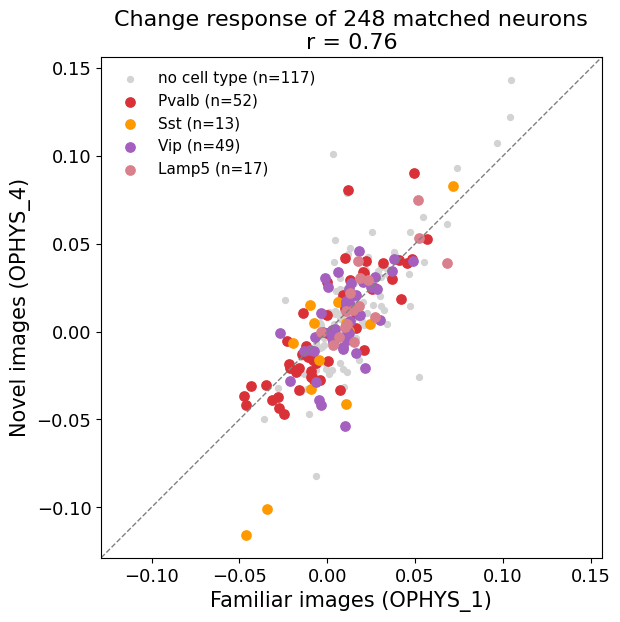

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))

# Untyped neurons in grey behind, so the typed ones are readable on top.
is_untyped = matched_neurons['subclass'].isna().values
ax.scatter(familiar_response[is_untyped], novel_response[is_untyped],
           color='lightgray', s=18, label=f'no cell type (n={is_untyped.sum()})')

for name in subclass_order:
    is_subclass = (matched_neurons['subclass'] == name).values
    ax.scatter(familiar_response[is_subclass], novel_response[is_subclass],
               color=subclass_colors[name], s=45, label=f'{name} (n={is_subclass.sum()})')

# Square axes covering ALL the data, with a small margin. Derive the limits rather than
# hardcoding them: a fixed range silently clips whichever neurons fall outside it, and a
# clipped scatter looks exactly like a complete one.
low = min(familiar_response.min(), novel_response.min())
high = max(familiar_response.max(), novel_response.max())
margin = 0.05 * (high - low)
axis_limits = [low - margin, high + margin]

# Unity line: points above it responded more to novel images, below more to familiar.
ax.plot(axis_limits, axis_limits, color='gray', linestyle='--', linewidth=1)

ax.set_xlim(axis_limits)
ax.set_ylim(axis_limits)
ax.set_aspect('equal')
ax.set_xlabel('Familiar images (OPHYS_1)')
ax.set_ylabel('Novel images (OPHYS_4)')
ax.set_title(f'Change response of {len(matched_neurons)} matched neurons\nr = {r_matched:.2f}')
ax.legend(frameon=False, fontsize=11)
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

A high correlation with a near-zero shuffled control tells us two things:

1. The matching is real. Random pairings give nothing.
2. How strongly a neuron responds to a change is a **stable property of that neuron**, holding up
   across a several-day gap and an entirely different image set.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Familiar versus novel, by cell type</h3>

Now the two sessions on the same axes, using **only the matched neurons**, so any difference cannot
be caused by a different set of cells. Solid is familiar, dashed is novel.

</div>

In [ ]:
fig, axes = plt.subplots(1, len(subclass_order), figsize=(17, 4.5), sharey=True)

for ax, name in zip(axes, subclass_order):
    is_subclass = (matched_neurons['subclass'] == name).values

    # This subclass's columns in each session's activity matrix. The two column sets
    # describe the SAME neurons, just numbered differently per session.
    familiar_columns = matched_neurons['familiar_column'][is_subclass]
    novel_columns = matched_neurons['novel_column'][is_subclass]

    familiar_mean_trace = familiar_change_aligned[:, familiar_columns].mean(axis=1)
    novel_mean_trace = novel_change_aligned[:, novel_columns].mean(axis=1)

    ax.plot(window, familiar_mean_trace, color=subclass_colors[name],
            linewidth=2, label='familiar (A)')
    ax.plot(window, novel_mean_trace, color=subclass_colors[name],
            linestyle='--', linewidth=2, label='novel (B)')

    shade_stimulus(ax, familiar_stimulus, window)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_title(f'{name} (n={is_subclass.sum()})')
    ax.set_xlabel('Time from change (s)')
    ax.legend(frameon=False, fontsize=11)

axes[0].set_ylabel(r'$\Delta$F/F change')
fig.tight_layout()
plt.show()

In [ ]:
matched_summary = pd.DataFrame({'familiar': familiar_response,
                                'novel': novel_response,
                                'subclass': matched_neurons['subclass'].values})

# One step at a time: group by cell type, then summarise the two response columns.
responses_by_subclass = matched_summary.groupby('subclass', observed=True)
response_summary = responses_by_subclass[['familiar', 'novel']].agg(['count', 'mean'])

response_summary.round(4)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Read this table with the sample sizes in mind. Some subclasses have only a dozen matched neurons in
one pair of sessions, which is not enough to conclude anything about that cell type. The way to make
such a comparison convincing is to repeat it over many session pairs and many mice, which is what
the full dataset supports.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>One neuron, two sessions, one transcriptome</h3>

The plot that shows what all this ID-matching bought us: the same physical neuron, recorded on two
days under two different image sets, with its cell type and its measured gene expression — three
separate measurements resolved to one cell.

</div>

In [ ]:
# Pick the most strongly responding typed neuron, so the traces are legible.
has_subclass = matched_neurons['subclass'].notna().values

typed_positions = np.where(has_subclass)[0]
strongest_among_typed = np.argmax(familiar_response[has_subclass])
example_index = typed_positions[strongest_among_typed]

example_neuron = matched_neurons.iloc[example_index]

print(example_neuron['unique_roicat_id'], '|', example_neuron['subclass'],
      '| hcr_id', int(example_neuron['hcr_id']))
print('familiar: plane', example_neuron['familiar_plane'],
      'column', example_neuron['familiar_column'])
print('novel:    plane', example_neuron['novel_plane'],
      'column', example_neuron['novel_column'])

Its transcriptomic side: the genes this cell expressed most strongly, read straight out of
the AnnData by `hcr_id`.

In [ ]:
example_cell = adata[str(int(example_neuron['hcr_id']))]
expression_values = np.asarray(example_cell.layers['normalized']).ravel()

example_expression = pd.Series(expression_values, index=adata.var['gene'].values)

top_genes = example_expression.sort_values(ascending=False).head(6)

print('top genes:')
print(top_genes.round(2).to_string())

In [ ]:
# One entry per session: everything the two panels need for that session's trace.
familiar_date = familiar_session['session_date']
novel_date = novel_session['session_date']

sessions_to_plot = [
    {'dff': familiar_dff_all, 'rois': familiar_rois, 'timestamps': familiar_timestamps,
     'change_aligned': familiar_change_aligned,
     'column': example_neuron['familiar_column'],
     'label': f'familiar (A) -- {familiar_date}', 'linestyle': '-'},
    {'dff': novel_dff_all, 'rois': novel_rois, 'timestamps': novel_timestamps,
     'change_aligned': novel_change_aligned,
     'column': example_neuron['novel_column'],
     'label': f'novel (B) -- {novel_date}', 'linestyle': '--'},
]

Left panel: the whole session, on that session's own clock for this neuron's plane. Right
panel: the same neuron's change-aligned mean, one line per session.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for session_data in sessions_to_plot:
    column = session_data['column']

    # This neuron's own plane, so we use the right clock for the whole-session trace.
    plane = session_data['rois']['plane'][column]
    time = session_data['timestamps'][plane]

    axes[0].plot(time, session_data['dff'][:, column], linewidth=0.4,
                 label=session_data['label'])

    axes[1].plot(window, session_data['change_aligned'][:, column], color='black',
                 linestyle=session_data['linestyle'], linewidth=2,
                 label=session_data['label'])

axes[0].set_xlabel('Time from session start (s)')
axes[0].set_ylabel(r'$\Delta$F/F')
axes[0].set_title('Whole session')
axes[0].legend(frameon=False, fontsize=11)

shade_stimulus(axes[1], familiar_stimulus, window)
axes[1].set_xlabel('Time from change (s)')
axes[1].set_title('Change-aligned')
axes[1].legend(frameon=False, fontsize=11)

subclass = example_neuron['subclass']
hcr_id = int(example_neuron['hcr_id'])
fig.suptitle(f'One {subclass} neuron (hcr_id {hcr_id}), two sessions')
fig.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Where to go next</h2>

The pieces are now in place to ask the questions this dataset was built for.

- **Follow neurons through the whole curriculum.** The `unique_roicat_id` intersection generalizes to
  any number of sessions. Intersect across all of them to get the neurons tracked from naive to
  expert, and watch their responses change. Decide `is_soma` once per neuron rather than per session
  before you do.
- **The novelty effect, properly.** Compare `OPHYS_1_images_A` (familiar), `OPHYS_4_images_B`
  (novel), and `OPHYS_6_images_B` (extinction: set B, no rewards). The three-way comparison separates
  novelty from image set from reward.
- **Extinction as its own question.** In `OPHYS_6_images_B` the mouse keeps licking at first and
  gets nothing, so the stimulus-reward association is being unlearned across the session. Splitting
  that session into early and late blocks, or tracking the lick rate alongside the neural response,
  is a learning question you can ask within a single session.
- **Change what you keep.** Drop the `is_soma` or the `hcr_id` filter in the subsetting cells and
  re-run any plot on a different population — for instance to check that a result on coregistered
  cells also holds in the full recorded population.
- **Use expression as a continuous variable.** Everything above treated cell type as a discrete
  label, but `adata.layers['normalized']` gives graded expression per cell. Correlating a functional
  metric against a single gene avoids committing to a clustering at all.
- **Use the finer clusters.** `adata.obs['cluster']` has ~30 clusters where `subclass` has four.
  There are fewer coregistered neurons per cluster, so this needs pooling across mice.
- **Omitted flashes.** Align to `omitted == True` in the stimulus table instead of to changes.
- **Hits versus misses.** Split `change_time` by trial outcome. Interpret differences beyond about a
  second after the change with care: by then the mouse has licked and consumed reward, so movement
  and reward are mixed in with vision.
- **Other mice.** `session_metadata['subject_id'].unique()` lists them. Each has its own
  coregistration table in the same asset and its own HCR AnnData.

Three cautions carried over from earlier parts. First, coregistered neurons are not a random sample
of segmented ROIs — they are biased toward somas and toward neurons that tracked reliably, and the
inhibitory subclasses sit at systematically different depths (Lamp5 and Vip superficial, Sst and
Pvalb deep), so a subclass difference is partly a depth difference. Compare like with like. Second, all joins go through `unique_roi_id` and
`unique_roicat_id`; the moment you find yourself indexing one session's array with another session's
positions, stop. Third, a selectivity index built as a ratio saturates when one of the two responses
is negative; check the sign before trusting the value.

</div>